In [ ]:
# Purge RAPIDS/CUDA stack that drags in old numba
to_remove = [
  "cuml-cu12","cudf-cu12","dask-cuda","distributed-ucxx-cu12",
  "ucx-py-cu12","rmm-cu12","raft-dask-cu12","rapidsai-cu12",
  "cuml","cudf","ucx-py","rmm","raft-dask","ucxx"
]
import subprocess, sys
for p in to_remove:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", p], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# (Re)install our clean CPU stack (safe if already installed)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
  "numpy==2.1.3","scipy==1.14.1","pandas==2.2.2",
  "scikit-learn==1.6.0","matplotlib==3.9.2",
  "lightgbm==4.5.0","category-encoders==2.6.3",
  "pyarrow==17.0.0","shap==0.46.0","statsmodels==0.14.2"
])

# Hard restart to load binaries cleanly
import os; os.kill(os.getpid(), 9)


In [ ]:
# Purge remaining RAPIDS GPU packages that keep shouting about rmm/cuDF dependencies
import subprocess, sys
leftovers = [
    "dask-cudf-cu12","pylibcugraph-cu12","ucxx-cu12",
    "pylibcudf-cu12","pylibraft-cu12","rmm-cu12","rapidsai-cu12"
]
for p in leftovers:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", p],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# (Re)ensure our CPU stack (safe if already present)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
  "numpy==2.1.3","scipy==1.14.1","pandas==2.2.2",
  "scikit-learn==1.6.0","matplotlib==3.9.2",
  "lightgbm==4.5.0","category-encoders==2.6.3",
  "pyarrow==17.0.0","shap==0.46.0","statsmodels==0.14.2"
])

# Restart to load binaries cleanly
import os; os.kill(os.getpid(), 9)


In [1]:
# ===== BLOCK 0B: Imports + seeds + folders =====
import os, time, json, warnings, random, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    log_loss, brier_score_loss, confusion_matrix
)

import lightgbm as lgb
import category_encoders as ce
import statsmodels.api as sm

SEED = 42
np.random.seed(SEED); random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

RUN_ID = time.strftime("%Y%m%d-%H%M%S")
BASE = Path(f"/content/runs/{RUN_ID}")
for d in ("data", "models", "figs", "logs", "preds"):
    (BASE / d).mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

meta = {
    "run_id": RUN_ID,
    "seed": SEED,
    "versions": {
        "python": sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sys.modules["sklearn"].__version__,
        "scipy": sys.modules["scipy"].__version__,
        "matplotlib": plt.matplotlib.__version__,
        "lightgbm": lgb.__version__,
        "category_encoders": ce.__version__,
        "statsmodels": sm.__version__,
    }
}
with open(BASE / "logs" / "env.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Environment ready.")
print(json.dumps(meta["versions"], indent=2))
print(f"BASE folder: {BASE}")


Environment ready.
{
  "python": "3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]",
  "numpy": "2.1.3",
  "pandas": "2.2.2",
  "scikit_learn": "1.6.0",
  "scipy": "1.14.1",
  "matplotlib": "3.9.2",
  "lightgbm": "4.5.0",
  "category_encoders": "2.6.3",
  "statsmodels": "0.14.2"
}
BASE folder: /content/runs/20250925-220230


In [2]:
# =========================
# BLOCK 1: Upload + prepare MOPS380 benchmark with next-day label
# =========================
from google.colab import files
import io, re
import numpy as np
import pandas as pd

print("Select the MOPS380_CI_SymbolPrice_*.csv file to upload…")
up = files.upload()
assert len(up) == 1, "Please upload exactly one MOPS380 CSV."
mops_name, mops_bytes = next(iter(up.items()))

def load_mops380(buf: bytes) -> pd.DataFrame:
    """
    Robust loader for MOPS380 csv:
    - Tries tidy CSV with Date/Close columns.
    - Falls back to 'row-labeled' format where the first column are labels/dates
      and numeric columns hold Close/High/Low.
    Returns a tidy df with ['date','close'] sorted by date.
    """
    # Try tidy first
    try:
        df = pd.read_csv(io.BytesIO(buf))
        date_col = next((c for c in df.columns if re.search(r"date", str(c), re.I)), None)
        close_col = next((c for c in df.columns if re.search(r"\bclose\b|\bsettle\b", str(c), re.I)), None)
        if date_col and close_col:
            out = df[[date_col, close_col]].copy()
            out.rename(columns={date_col: "date", close_col: "close"}, inplace=True)
            out["date"]  = pd.to_datetime(out["date"], errors="coerce")
            out["close"] = pd.to_numeric(out["close"], errors="coerce")
            out = out.dropna().sort_values("date").reset_index(drop=True)
            if len(out) > 0:
                return out
    except Exception:
        pass

    # Fallback: row-labeled format (first col holds strings; some rows are dates)
    raw = pd.read_csv(io.BytesIO(buf), header=None)
    # Identify which rows in col0 parse as dates
    cand_dates = pd.to_datetime(raw[0], errors="coerce")
    date_rows = raw[cand_dates.notna()].copy()
    if date_rows.empty:
        raise ValueError("Could not detect date rows in MOPS file.")

    # Heuristic to pick the 'Close' column:
    # 1) look in the top block for a column mentioning 'Close'/'Settle'
    close_idx = None
    top = raw.head(60).astype(str).apply(lambda s: " ".join(s.str.lower()), axis=0)
    for j in range(1, min(raw.shape[1], 8)):
        if any(k in top.iloc[j] for k in (" close", "close ", "settle", "settlement", "price ")):
            close_idx = j; break
    # 2) fallback: most numeric column to the right
    if close_idx is None:
        numeric_share = []
        for j in range(1, raw.shape[1]):
            s = pd.to_numeric(raw[j], errors="coerce")
            numeric_share.append((np.isfinite(s).mean(), j))
        numeric_share.sort(reverse=True)
        close_idx = numeric_share[0][1]

    out = pd.DataFrame({
        "date":  pd.to_datetime(date_rows[0].values, errors="coerce"),
        "close": pd.to_numeric(date_rows[close_idx].values, errors="coerce")
    }).dropna()
    out = out.sort_values("date").reset_index(drop=True)
    return out

mops = load_mops380(mops_bytes)

# Basic cleaning: drop duplicates, forward-fill tiny gaps if any (optional)
mops = mops.drop_duplicates(subset=["date"]).sort_values("date").reset_index(drop=True)

# Sanity checks for HSFO 380 levels (USD/mt)
vmin, v50, vmax = mops["close"].min(), mops["close"].median(), mops["close"].max()
print(f"[MOPS380] rows={len(mops)}  range={mops['date'].min().date()}→{mops['date'].max().date()}")
print(f"[MOPS380] close stats: min={vmin:.2f}, median={v50:.2f}, max={vmax:.2f}")

assert 30 <= vmin <= 4000, "Close min looks implausible for HSFO 380."
assert 50 <= v50 <= 1200,  "Close median looks implausible for HSFO 380."
assert vmin < v50 < vmax,  "Close distribution not monotone as expected."

# --- Create next-day label y_t = 1[r_{t+1} > 0] ---
mops = mops.sort_values("date").reset_index(drop=True)
mops["close_next"] = mops["close"].shift(-1)
mops["ret_next"]   = (mops["close_next"] - mops["close"]) / mops["close"]
mops["y_bin"]      = (mops["ret_next"] > 0).astype("Int8")   # 1 = up, 0 = down
mops["y_str"]      = np.where(mops["y_bin"] == 1, "up", "down")

# Drop the very last row with NaN next-day
mops = mops.dropna(subset=["close_next", "ret_next"]).reset_index(drop=True)

# Save tidy benchmark with labels
from pathlib import Path
out_path = (BASE / "data" / "mops380_labeled.parquet")
mops.to_parquet(out_path, index=False)

print("\n✅ MOPS380 parsed and labeled.")
print(mops.tail(5))
print(f"\nSaved labeled benchmark → {out_path}")


Select the MOPS380_CI_SymbolPrice_*.csv file to upload…


Saving MOPS380_CI_SymbolPrice_2025-06-02T030407Z.csv to MOPS380_CI_SymbolPrice_2025-06-02T030407Z.csv
[MOPS380] rows=3955  range=2009-08-14→2025-05-30
[MOPS380] close stats: min=101.36, median=436.27, max=743.27

✅ MOPS380 parsed and labeled.
           date   close  close_next  ret_next  y_bin y_str
3949 2025-05-23  431.41      428.53 -0.006676      0  down
3950 2025-05-26  428.53      420.45 -0.018855      0  down
3951 2025-05-27  420.45      428.38  0.018861      1    up
3952 2025-05-28  428.38      434.66  0.014660      1    up
3953 2025-05-29  434.66      420.31 -0.033014      0  down

Saved labeled benchmark → /content/runs/20250925-220230/data/mops380_labeled.parquet


In [3]:
# =========================
# BLOCK 2: Upload HEARDS, clean, and make time splits (by day)
# =========================
from google.colab import files
import io
import numpy as np
import pandas as pd

print("Select heards_structured_cleaned_v11.csv …")
up = files.upload()
assert len(up) == 1, "Please upload exactly one HEARDS CSV."
heards_name, heards_bytes = next(iter(up.items()))

# Load
heards = pd.read_csv(io.BytesIO(heards_bytes))

# Basic schema sanity
expected_cols = {
    "updatedDate","start_date","end_date","action_type","party","price",
    "price_basis","location","volume_min","volume_max","headline","duration_days"
}
missing = expected_cols - set(heards.columns)
if missing:
    print(f"WARNING: missing columns: {sorted(missing)} (continuing)")

# Parse dates; coerce text; lightweight cleaning
for c in ("updatedDate","start_date","end_date"):
    if c in heards.columns:
        heards[c] = pd.to_datetime(heards[c], errors="coerce")
if "headline" in heards.columns:
    heards["headline"] = heards["headline"].astype(str).fillna("")

# Derive daily key (we'll align to daily later; here we just normalize to date)
heards["day"] = heards["updatedDate"].dt.tz_localize(None).dt.normalize()

# Load the labeled MOPS (from Block 1 output) to get coverage window
mops = pd.read_parquet(BASE / "data" / "mops380_labeled.parquet")
mops_min_day = mops["date"].min()
mops_max_day = mops["date"].max()   # note: last day has next-day label computed already

# Filter HEARDS to MOPS coverage so that every HEARDS day can map to a label
mask_cov = (heards["day"] >= mops_min_day) & (heards["day"] <= mops_max_day)
heards_cov = heards.loc[mask_cov].copy()

# Sort chronologically
heards_cov = heards_cov.sort_values(["day","updatedDate"]).reset_index(drop=True)

print(f"HEARDS (raw) shape: {heards.shape}")
print(f"HEARDS (within MOPS coverage) shape: {heards_cov.shape}")
print(f"HEARDS day range in coverage: {heards_cov['day'].min().date()} → {heards_cov['day'].max().date()}")

# ----- Time-based split by *unique day* (70/15/15) -----
unique_days = np.array(sorted(heards_cov["day"].dropna().unique()))
n_days = len(unique_days)
assert n_days > 50, "Not enough distinct days after filtering for a meaningful split."

i_train_end = int(0.70 * n_days)
i_val_end   = int(0.85 * n_days)

train_days = set(unique_days[:i_train_end])
val_days   = set(unique_days[i_train_end:i_val_end])
test_days  = set(unique_days[i_val_end:])

# Build row masks (row belongs to split if its 'day' is in the split day-set)
train_mask = heards_cov["day"].isin(train_days)
val_mask   = heards_cov["day"].isin(val_days)
test_mask  = heards_cov["day"].isin(test_days)

def _span(ds):
    return (min(ds).date(), max(ds).date()) if len(ds) else (None, None)

print("\nSplit by day (70/15/15):")
print(f"  Train days: {len(train_days)}  span={_span(train_days)}")
print(f"  Val   days: {len(val_days)}    span={_span(val_days)}")
print(f"  Test  days: {len(test_days)}   span={_span(test_days)}")

print("\nRow counts:")
print(f"  Train rows: {train_mask.sum():,}")
print(f"  Val   rows: {val_mask.sum():,}")
print(f"  Test  rows: {test_mask.sum():,}")

# Persist split info (by day) so we can reapply after merging/aggregation
split_info = pd.DataFrame({
    "day": unique_days,
    "split": (["train"]*len(train_days) + ["val"]*len(val_days) + ["test"]*len(test_days))
})
split_info.to_parquet(BASE / "data" / "heards_day_splits.parquet", index=False)

# Save the filtered HEARDS for next steps
heards_cov.to_parquet(BASE / "data" / "heards_cov.parquet", index=False)

print("\n✅ HEARDS uploaded, filtered to MOPS coverage, and split by day.")
print(f"Saved: {BASE/'data'/'heards_cov.parquet'}")
print(f"Saved: {BASE/'data'/'heards_day_splits.parquet'}")


Select heards_structured_cleaned_v11.csv …


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv
HEARDS (raw) shape: (154903, 13)
HEARDS (within MOPS coverage) shape: (154903, 13)
HEARDS day range in coverage: 2017-06-15 → 2025-05-23

Split by day (70/15/15):
  Train days: 1386  span=(datetime.date(2017, 6, 15), datetime.date(2022, 12, 27))
  Val   days: 297    span=(datetime.date(2022, 12, 28), datetime.date(2024, 3, 13))
  Test  days: 297   span=(datetime.date(2024, 3, 14), datetime.date(2025, 5, 23))

Row counts:
  Train rows: 122,972
  Val   rows: 15,362
  Test  rows: 16,569

✅ HEARDS uploaded, filtered to MOPS coverage, and split by day.
Saved: /content/runs/20250925-220230/data/heards_cov.parquet
Saved: /content/runs/20250925-220230/data/heards_day_splits.parquet


In [5]:
# =========================
# BLOCK 3 (fixed): Daily aggregation of HEARDS + merge with MOPS labels
# =========================
import numpy as np, pandas as pd
from collections import Counter
from math import log

# Reload inputs (in case of prior partial state)
mops       = pd.read_parquet(BASE / "data" / "mops380_labeled.parquet")
heards_cov = pd.read_parquet(BASE / "data" / "heards_cov.parquet")
splits     = pd.read_parquet(BASE / "data" / "heards_day_splits.parquet")  # day, split

# Ensure types
for c in ("action_type","party","price_basis","location","headline"):
    if c in heards_cov.columns:
        heards_cov[c] = heards_cov[c].astype(str).fillna("")
heards_cov["day"] = pd.to_datetime(heards_cov["day"], errors="coerce")
heards_cov = heards_cov.dropna(subset=["day"])

# Helper
def shannon_entropy(values):
    if not values: return 0.0
    c = Counter(values); n = sum(c.values())
    ps = [v/n for v in c.values()]
    return -sum(p*log(p+1e-12) for p in ps)

# --- Aggregation (safe 1D outputs only) ---
gb = heards_cov.groupby("day", as_index=False)

# base daily frame with counts
if "headline" in heards_cov.columns:
    daily = gb["headline"].size().rename(columns={"size": "headline_count"})
else:
    daily = gb["updatedDate"].size().rename(columns={"size": "headline_count"})

# party features
if "party" in heards_cov.columns:
    tmp = gb["party"].agg(list).rename(columns={"party":"party_list"})
    daily = daily.merge(tmp, on="day", how="left")
    daily["party_unique"]  = daily["party_list"].apply(lambda L: len(set(L)) if isinstance(L, list) else 0)
    daily["party_entropy"] = daily["party_list"].apply(lambda L: shannon_entropy(L) if isinstance(L, list) else 0.0)
else:
    daily["party_unique"] = 0
    daily["party_entropy"] = 0.0

# location features
if "location" in heards_cov.columns:
    tmp = gb["location"].agg(list).rename(columns={"location":"loc_list"})
    daily = daily.merge(tmp, on="day", how="left")
    daily["loc_unique"]  = daily["loc_list"].apply(lambda L: len(set(L)) if isinstance(L, list) else 0)
    daily["loc_entropy"] = daily["loc_list"].apply(lambda L: shannon_entropy(L) if isinstance(L, list) else 0.0)
else:
    daily["loc_unique"] = 0
    daily["loc_entropy"] = 0.0

# concatenate day text for later TF-IDF
if "headline" in heards_cov.columns:
    txt = gb["headline"].apply(lambda s: " \n ".join(map(str, s))).rename(columns={"headline":"text_day"})
    daily = daily.merge(txt, on="day", how="left")
else:
    daily["text_day"] = ""

# drop helper list columns
for col in ("party_list","loc_list"):
    if col in daily.columns:
        daily = daily.drop(columns=[col])

# calendar features
daily = daily.sort_values("day").reset_index(drop=True)
daily["doy"]   = daily["day"].dt.dayofyear
daily["dow"]   = daily["day"].dt.dayofweek
daily["month"] = daily["day"].dt.month

# --- Merge MOPS labels (align day→date) ---
merged = daily.merge(mops.rename(columns={"date":"day"}), on="day", how="inner")
merged = merged.dropna(subset=["y_bin","ret_next","close"]).reset_index(drop=True)

# reapply split by day (no leakage)
merged = merged.merge(splits, on="day", how="left")

print("Merged supervised dataset (head):")
print(merged[["day","headline_count","party_unique","loc_unique","close","ret_next","y_bin","split"]].head(10))
print("\nCounts by split:")
print(merged["split"].value_counts(dropna=False))

# Save
merged_path = BASE / "data" / "supervised_daily.parquet"
merged.to_parquet(merged_path, index=False)
print(f"\n✅ Saved daily supervised dataset → {merged_path}")


Merged supervised dataset (head):
         day  headline_count  party_unique  loc_unique   close  ret_next  \
0 2017-06-15              51            11           2  283.92  0.004403   
1 2017-06-16             109            10           1  285.17  0.003822   
2 2017-06-19             103             8           1  286.26  0.000279   
3 2017-06-20             131            10           1  286.34 -0.018789   
4 2017-06-21             143            10           1  280.96 -0.011995   
5 2017-06-22             105             8           1  277.59  0.010339   
6 2017-06-23              75             7           1  280.46  0.016580   
7 2017-06-27             118             9           1  285.11  0.003437   
8 2017-06-28              83            10           1  286.09  0.016254   
9 2017-06-29              80             9           1  290.74  0.012382   

   y_bin  split  
0      1  train  
1      1  train  
2      1  train  
3      0  train  
4      0  train  
5      1  train  
6  

# HSFO-380 Next-Day Direction — Data Preparation & Supervised Labeling (Setup Notes)

## 1. Data sources

- **Benchmark price series (MOPS380).** A historical daily series for **HSFO 380cst 3.5%S FOB Singapore** (MOPS 380), parsed to a tidy table  
  \[
  \mathcal{P} \;=\; \{(t,\, C_t)\}_{t=1}^T,\quad t\in\text{trading days},\; C_t \in \mathbb{R}_{>0}
  \]
  where \(C_t\) is the **Close** on day \(t\).

- **Headline/event corpus (HEARDS).** A time-stamped set of structured records with columns such as  
  \(\texttt{updatedDate}, \texttt{action\_type}, \texttt{party}, \texttt{price\_basis}, \texttt{location}, \texttt{volume\_min}, \texttt{volume\_max}, \texttt{headline}, \ldots\).

> **Note.** Any `price` field inside HEARDS is treated as a **feature**, not as the benchmark \(C_t\).

---

## 2. Benchmark cleaning and labeling

We construct a **binary next-day direction label** from the benchmark:

1. **Return definition.** Using arithmetic return for interpretability,
   \[
   r_{t+1} \;=\; \frac{C_{t+1}-C_t}{C_t}.
   \]

2. **Binary label.**
   \[
   y_t \;=\; \mathbf{1}\!\left[r_{t+1} > 0\right] \;\in\; \{0,1\},
   \]
   where \(y_t = 1\) denotes **up** on day \(t+1\), and \(y_t=0\) denotes **down**.

3. **Implementation details.**
   - CSV variations (tidy vs. row-labeled) are robustly parsed; the output is a tidy frame with columns \((\texttt{date}, \texttt{close})\).
   - We create `close_next`, `ret_next`, `y_bin` (0/1), and `y_str` (“up”/“down”).
   - The terminal day is dropped when `close_next` is missing.

The resulting labeled series is saved as:
/runs/<RUN_ID>/data/mops380_labeled.parquet

---

## 3. HEARDS normalization and daily aggregation

We collapse intraday/event-level HEARDS rows to a **single daily record** per calendar day \(t\). Let \(\mathcal{H}_t\) be the multiset of HEARDS rows with `updatedDate` on day \(t\). We derive the following day-level features:

1. **Headline intensity.**
   \[
   \text{count}_t \;=\; |\mathcal{H}_t|.
   \]

2. **Entity diversity (party/location).** For a categorical field \(X\in\{\texttt{party}, \texttt{location}\}\),
   - Unique count:
     \[
     u_t^{(X)} \;=\; \big|\{x:\; x\in \mathcal{H}_t\}\big|.
     \]
   - Shannon entropy (base \(e\)) to capture concentration vs. dispersion:
     \[
     H_t^{(X)} \;=\; -\sum_{x} p_t(x)\,\log\!\big(p_t(x)+\epsilon\big),\qquad
     p_t(x) \;=\; \frac{\#\{h\in\mathcal{H}_t: X(h)=x\}}{|\mathcal{H}_t|},
     \]
     with a small \(\epsilon>0\) for numerical stability when \(p_t(x)=0\).

3. **Text concatenation for later NLP.** All `headline` strings within day \(t\) are concatenated to obtain a day-level text field
   \[
   \text{text\_day}_t \;=\; \text{concat}\big(\{\texttt{headline}(h): h\in\mathcal{H}_t\}\big),
   \]
   which will feed TF-IDF \(\to\) SVD in the modeling stage.

4. **Calendar encodings.** Deterministic features such as day of week, month, and day-of-year:
   \[
   \text{dow}_t=\text{DoW}(t),\quad \text{month}_t=\text{Month}(t),\quad \text{doy}_t=\text{DoY}(t).
   \]

The aggregated daily table is then **inner-joined** with the labeled benchmark by \(\texttt{day}\equiv \texttt{date}\), yielding a supervised dataset:
\[
\mathcal{D} \;=\; \{(X_t,\, y_t)\}_{t=t_0}^{t_1},
\]
where \(X_t\) includes \(\text{count}_t, u_t^{(X)}, H_t^{(X)}, \text{dow}_t, \text{month}_t, \text{doy}_t, \text{text\_day}_t,\ldots\), and \(y_t\) is defined in §2.

Saved as:
/runs/<RUN_ID>/data/supervised_daily.parquet

---

## 4. Temporal scope and coverage control

- HEARDS is filtered to the **date range covered by MOPS** \([t_{\min}^{\text{MOPS}},\, t_{\max}^{\text{MOPS}}]\) so that each daily HEARDS record has a corresponding benchmark label.
- Duplicates are dropped; all timestamps are normalized to date (no timezone leakage).

---

## 5. Time-based data splitting (leakage-safe)

We perform a **chronological split** by unique days (no shuffling):

- Let \(\mathcal{T}\) be the ordered set of unique days after the merge. We partition:
  \[
  \mathcal{T}\;=\;\mathcal{T}_{\text{train}}\;\cup\;\mathcal{T}_{\text{val}}\;\cup\;\mathcal{T}_{\text{test}},
  \quad \text{with } \mathcal{T}_{\text{train}} < \mathcal{T}_{\text{val}} < \mathcal{T}_{\text{test}}
  \]
  by a fixed ratio (e.g., **70/15/15**), preserving time order.

- A row with day \(t\) is assigned to the split determined by \(t\in\mathcal{T}_\bullet\). These split assignments are persisted and re-used in later feature engineering and model fitting to ensure **no information from the future leaks into the past**.

Saved as:
/runs/<RUN_ID>/data/heards_day_splits.parquet

---

## 6. Sanity checks performed

- **Price plausibility.** Verified \(\min C_t\), \(\text{median}(C_t)\), and \(\max C_t\) fall in reasonable HSFO 380 ranges and \(\min<\text{median}<\max\).
- **Join density.** Confirmed adequate counts per split (train/val/test) after inner-join.
- **Terminal label handling.** Dropped last day where \(C_{t+1}\) is unavailable.

---

## 7. What comes next (methodological roadmap)

> The following steps are **not yet executed** here but are enabled by the current setup and will be added in subsequent blocks:

1. **Variance-aware labeling (Paper 2, LES).**  
   Estimate a time-varying variance \(\widehat{\sigma}_t^2\) from the return series \(\{r_t\}\) via **Local Exponential Smoothing** with convex aggregation. Use \(\widehat{\sigma}_t\) to:
   - (a) **Denoise** labels by dropping/flagging ambiguous days with \(|r_{t+1}|\le c\,\widehat{\sigma}_t\).
   - (b) **Weight** the loss function (optional) to reflect heteroskedasticity.

2. **Adaptive training window (Paper 1, local homogeneity).**  
   Before each fit, select the **longest recent window** over which model fit statistics are stable (likelihood-ratio style checks across nested windows). This mitigates **concept drift**.

3. **Feature construction (time-safe).**  
   - Numerical lags and rolling statistics computed **using past-only** information.  
   - Text channel: TF-IDF on \(\text{text\_day}_t\) \(\to\) Truncated SVD to obtain a fixed-dimensional representation.  
   - Categorical encoders with **time-aware** out-of-fold target encoding.

4. **Models (classification only).**  
   - **Logistic Regression (SAGA)** with calibration.  
   - **Linear SVM** with probability calibration.  
   - **LightGBM** (shallow) for non-linearities.  
   All trained/evaluated with the chronological splits and, where relevant, the LES-based denoising/weights.

5. **Evaluation & figures (theory-centric).**  
   - **Loss/optimization traces** (log-loss vs. iteration; gradient/weight norms for LR).  
   - **ROC & PR curves**, **log-loss**, **Brier score**, **balanced accuracy**, **MCC**.  
   - **Calibration** (reliability diagrams, ECE).  
   - **Label diagnostics**: \(\widehat{\sigma}_t\) trajectory and performance vs. denoising threshold \(c\).  
   - **Drift diagnostics**: selected window length over time from local-homogeneity tests.

---

## 8. Notation summary

- \(C_t\): benchmark close price on day \(t\).  
- \(r_{t+1} = (C_{t+1}-C_t)/C_t\): next-day return.  
- \(y_t = \mathbf{1}[r_{t+1}>0]\): binary next-day direction label.  
- \(\mathcal{H}_t\): set of HEARDS records with timestamp in day \(t\).  
- \(\text{count}_t, u_t^{(X)}, H_t^{(X)}\): intensity, unique counts, and entropy features from \(\mathcal{H}_t\).  
- \(\text{text\_day}_t\): concatenated daily text for NLP features.  
- \(\widehat{\sigma}_t\): LES variance proxy for \(r_t\) (to be introduced later).

---

**Artifacts written**
- `data/mops380_labeled.parquet` — labeled benchmark \((C_t, r_{t+1}, y_t)\)  
- `data/heards_cov.parquet` — HEARDS filtered to MOPS coverage  
- `data/heards_day_splits.parquet` — chronological split by day (70/15/15)  
- `data/supervised_daily.parquet` — merged day-level features \(X_t\) with labels \(y_t\)


In [6]:
# =========================
# BLOCK 4: LES-style variance, ambiguity flags, and sample weights
# =========================
import numpy as np, pandas as pd
from pathlib import Path

# Load supervised daily dataset with y_t = 1[r_{t+1} > 0]
merged_path = BASE / "data" / "supervised_daily.parquet"
df = pd.read_parquet(merged_path).sort_values("day").reset_index(drop=True)

# --- 1) Compute daily returns r_t (today's return) from the Close ---
# We will use r_t to estimate sigma_t, which will be compared to r_{t+1} (already in df['ret_next'])
df["ret"] = df["close"].pct_change()
# For safety, drop the first NaN return row later when needed (but keep alignment for now)

# --- 2) Weak EWMA variance estimators v_k,t for multiple memory parameters (alphas) ---
# We'll aggregate them via a simple likelihood-based convex weighting (LES-style idea).
alphas = [0.05, 0.1, 0.2, 0.3]  # short -> long memory
eps = 1e-8

v_grid = {}
for a in alphas:
    # EWMA of squared returns; use bias floor for numerical stability
    v = df["ret"].pow(2).ewm(alpha=a, adjust=False, min_periods=5).mean().fillna(method="bfill")
    v = v.clip(lower=1e-8)
    v_grid[a] = v.values

V = np.column_stack([v_grid[a] for a in alphas])   # shape: [T, K]
K = V.shape[1]

# --- 3) Likelihood-based online weights over weak estimators (Gaussian assumption) ---
# For each k: loglik_k(t) = sum_{s<=t} [ -0.5*(log(2π v_k,s) + r_s^2 / v_k,s) ].
# To reduce numerical drift, we compute cumulative sums and stabilize with a temperature parameter.
r = df["ret"].fillna(0.0).values
loglik = np.zeros((len(df), K))
for k in range(K):
    vk = V[:, k]
    # Instant log-likelihood increments
    inc = -0.5 * (np.log(2*np.pi*vk) + (r**2) / np.maximum(vk, eps))
    loglik[:, k] = np.cumsum(inc)

# Temperature for softmax weighting; lower => peakier weights
tau = 1.0
# Normalize weights at each time by subtracting the per-time max loglik
m = loglik.max(axis=1, keepdims=True)
w_raw = np.exp((loglik - m) / tau)
w = w_raw / w_raw.sum(axis=1, keepdims=True)

# --- 4) Aggregated variance and sigma at time t (built only from info up to t) ---
v_agg = (w * V).sum(axis=1)
sigma_agg = np.sqrt(np.maximum(v_agg, eps))
df["les_sigma"] = sigma_agg

# --- 5) Ambiguity flags |r_{t+1}| <= c * sigma_t for several c thresholds ---
c_grid = [0.10, 0.15, 0.20]
for c in c_grid:
    df[f"ambig_c{int(c*100)}"] = (df["ret_next"].abs() <= c * df["les_sigma"]).astype("Int8")

# --- 6) Sample weights (optional): downweight very noisy days, upweight calm days ---
# Use inverse-variance with clipping to keep stability
invvar = 1.0 / np.maximum(df["les_sigma"]**2, 1e-8)
# Normalize to median=1, clip to a sensible range
invvar /= np.median(invvar[np.isfinite(invvar)])
df["w_invvar"] = np.clip(invvar, 0.25, 4.0)

# Housekeeping: drop the very first row if ret is NaN (no past info), and keep splits
df = df.dropna(subset=["ret"]).reset_index(drop=True)

# Quick sanity prints
print("LES sigma summary:")
print(df["les_sigma"].describe(percentiles=[0.1,0.5,0.9]))
for c in c_grid:
    col = f"ambig_c{int(c*100)}"
    print(f"Ambiguity rate at c={c:.2f}: {df[col].mean():.3f}")

# Save enhanced dataset
out_path = BASE / "data" / "supervised_daily_les.parquet"
df.to_parquet(out_path, index=False)
print(f"\n✅ Saved LES-enhanced dataset → {out_path}")
print("Columns now include: ['ret','les_sigma','w_invvar', 'ambig_c10','ambig_c15','ambig_c20', ...]")


LES sigma summary:
count    1975.000000
mean        0.024056
std         0.016169
min         0.003878
10%         0.010796
50%         0.019474
90%         0.041945
max         0.155411
Name: les_sigma, dtype: float64
Ambiguity rate at c=0.10: 0.086
Ambiguity rate at c=0.15: 0.126
Ambiguity rate at c=0.20: 0.163

✅ Saved LES-enhanced dataset → /content/runs/20250925-220230/data/supervised_daily_les.parquet
Columns now include: ['ret','les_sigma','w_invvar', 'ambig_c10','ambig_c15','ambig_c20', ...]


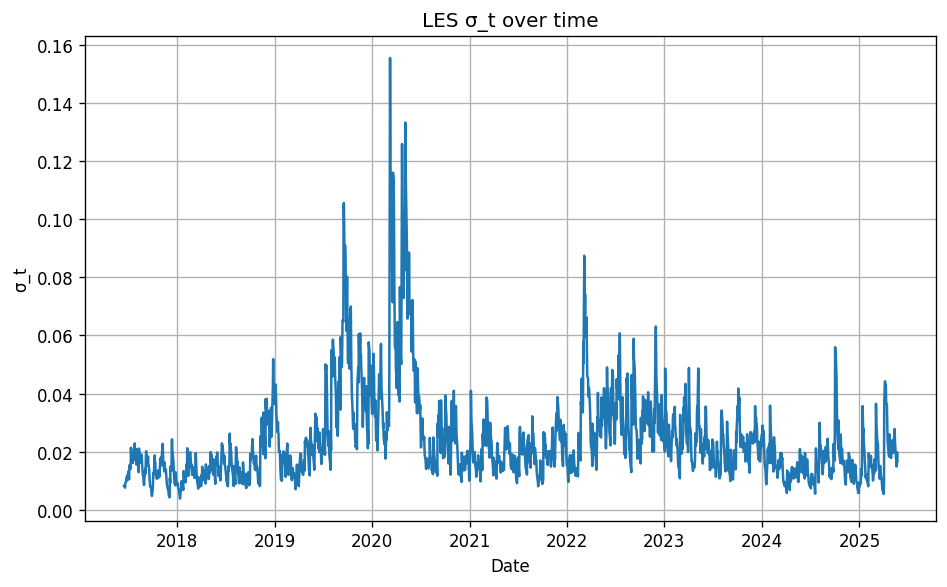

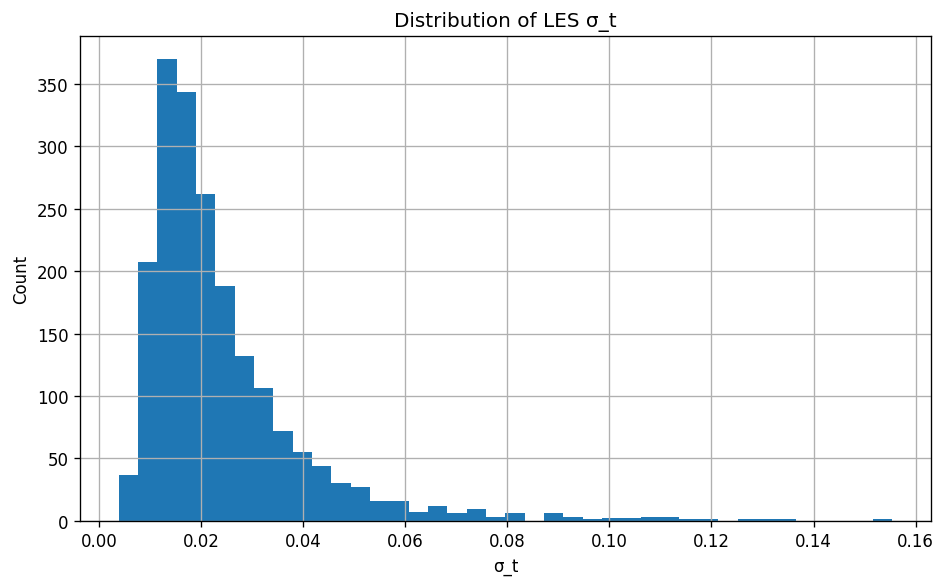

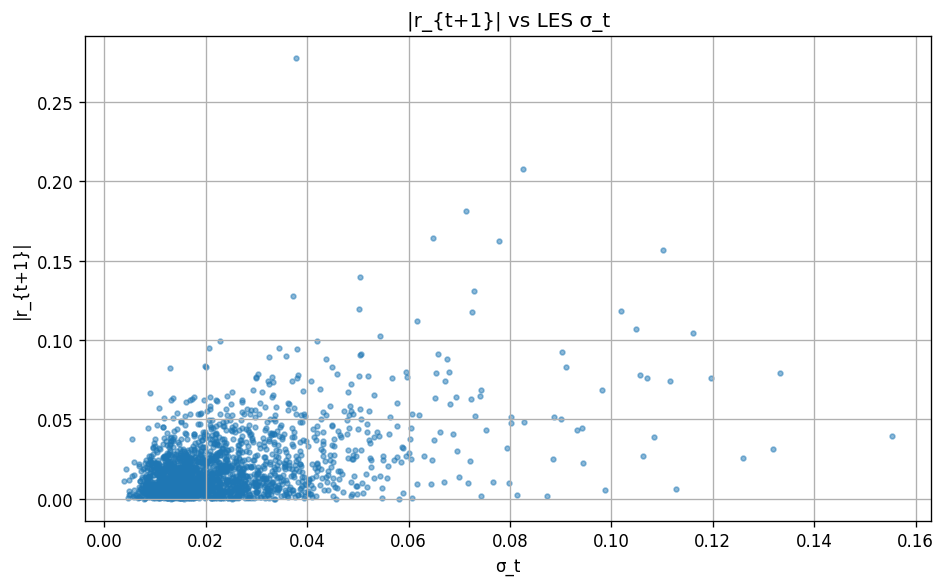

Ambiguity rate by year (c=0.10):
year
2017    0.044
2018    0.089
2019    0.064
2020    0.101
2021    0.079
2022    0.088
2023    0.099
2024    0.099
2025    0.094
Ambiguity rate by year (c=0.15):
year
2017    0.081
2018    0.117
2019      0.1
2020    0.149
2021    0.115
2022    0.128
2023     0.14
2024    0.155
2025    0.125
Ambiguity rate by year (c=0.20):
year
2017    0.118
2018    0.161
2019    0.128
2020    0.181
2021    0.155
2022    0.172
2023    0.173
2024     0.19
2025    0.167


In [7]:
# ===== Quick LES diagnostics (optional but recommended) =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day")

# 1) Sigma over time
plt.figure()
plt.plot(df["day"], df["les_sigma"])
plt.title("LES σ_t over time")
plt.xlabel("Date"); plt.ylabel("σ_t")
plt.tight_layout(); plt.show()

# 2) Histogram of σ_t
plt.figure()
plt.hist(df["les_sigma"].values, bins=40)
plt.title("Distribution of LES σ_t")
plt.xlabel("σ_t"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

# 3) |r_{t+1}| vs σ_t scatter (should trend upward)
plt.figure()
plt.scatter(df["les_sigma"].values, np.abs(df["ret_next"].values), s=8, alpha=0.5)
plt.title("|r_{t+1}| vs LES σ_t")
plt.xlabel("σ_t"); plt.ylabel("|r_{t+1}|")
plt.tight_layout(); plt.show()

# 4) Ambiguity rates by year (sanity)
df["year"] = df["day"].dt.year
for c in (10,15,20):
    rates = df.groupby("year")[f"ambig_c{c}"].mean()
    print(f"Ambiguity rate by year (c={c/100:.2f}):")
    print(rates.round(3).to_string())


# Feature Construction & Learning Objective

## 1. Prediction target
We predict next-day direction using information available at day \(t\).
Let \(C_t\) be the close and
\[
r_{t+1}=\frac{C_{t+1}-C_t}{C_t},\qquad
y_t=\mathbf{1}[r_{t+1}>0]\in\{0,1\}.
\]

## 2. Variance-aware metadata (from LES)
From daily returns \(\{r_t\}\), we estimate a time-varying volatility \(\hat\sigma_t\).
We keep **all** samples and optionally define:
- ambiguity indicator: \(\mathsf{ambig}_t(c)=\mathbf{1}\{|r_{t+1}|\le c\,\hat\sigma_t\}\),
- sample weights (optional): \(w_t \propto 1/\hat\sigma_t^2\) (clipped, median-normalized).

These do **not** leak future info: \(\hat\sigma_t\) is computed from \(\{r_s\}_{s\le t}\).

## 3. Feature map
For each day \(t\) we build \(X_t=[X_t^{\text{num}}, X_t^{\text{text}}]\).

### 3.1 Numerical channel (time-safe)
From daily aggregates of HEARDS:
\[
X_t^{\text{num}}=\Big[
\text{count}_t,\;
u_t^{(\text{party})},\; H_t^{(\text{party})},\;
u_t^{(\text{loc})},\; H_t^{(\text{loc})},\;
\text{dow}_t,\;\text{month}_t,\;\text{doy}_t,\;
\log C_t,\; r_t
\Big],
\]
standardized by \(\hat\mu, \hat\sigma\) computed **on the training slice only**.

### 3.2 Text channel
From the concatenated day text \(\text{text\_day}_t\),
build TF-IDF features on the training slice and apply to val/test:
- **word** n-grams, \(n\in\{1,2\}\),
- **character** n-grams, \(n\in\{3,4,5\}\).

Let \(Z_t\in\mathbb{R}^{D}\) be the sparse TF-IDF vector (word⊕char).
Project to \(d\ll D\) via Truncated SVD:
\[
X_t^{\text{text}} = SVD_d(Z_t)\in\mathbb{R}^{d}.
\]

## 4. Learning objective (Logistic Regression)
Let \(p_t=\sigma(\beta^\top X_t)\) with \(\sigma(u)=1/(1+e^{-u})\).
We fit \(\beta\) by minimizing **penalized, (optionally) weighted cross-entropy**:
\[
\min_{\beta}\;\frac{1}{N}\sum_{t\in\mathcal{T}_{\text{train}}}
\underbrace{w_t}_{\text{optional}}
\Big(-y_t\log p_t-(1-y_t)\log(1-p_t)\Big)
\;+\;\lambda\|\beta\|_2^2,
\]
with `class_weight="balanced"` to offset class skew. Regularization \(\lambda\) is set via \(C=1/\lambda\).

## 5. Calibration and evaluation
After fitting on **train**, we calibrate probabilities on **val** (isotonic),
then report metrics on **val** and **test**:
- log-loss, Brier, accuracy/balanced-accuracy, ROC-AUC/PR-AUC.

All transforms (scalers, vectorizers, SVD) are **fit on train** and reused on val/test → no leakage.


In [9]:
# =========================
# BLOCK 3+ (fixed): Enrich daily features to cover remaining HEARDS columns
# =========================
import numpy as np, pandas as pd
from collections import Counter
from math import log

mops    = pd.read_parquet(BASE / "data" / "mops380_labeled.parquet")
heards  = pd.read_parquet(BASE / "data" / "heards_cov.parquet")
splits  = pd.read_parquet(BASE / "data" / "heards_day_splits.parquet")

# Ensure types
for c in ("action_type","party","price_basis","location","headline"):
    if c in heards.columns:
        heards[c] = heards[c].astype(str).fillna("")
heards["day"] = pd.to_datetime(heards["day"], errors="coerce")
heards = heards.dropna(subset=["day"]).sort_values(["day","updatedDate"]).reset_index(drop=True)

def shannon_entropy(values):
    if not values: return 0.0
    c = Counter(values); n = sum(c.values())
    ps = [v/n for v in c.values()]
    return -sum(p*log(p+1e-12) for p in ps)

gb = heards.groupby("day", as_index=False)

# Base count
daily = gb.size().rename(columns={"size":"headline_count"})

# party/location diversity
for col, pref in [("party","party"), ("location","loc")]:
    if col in heards.columns:
        tmp = gb[col].agg(list).rename(columns={col:f"{pref}_list"})
        daily = daily.merge(tmp, on="day", how="left")
        daily[f"{pref}_unique"]  = daily[f"{pref}_list"].apply(lambda L: len(set(L)) if isinstance(L,list) else 0)
        daily[f"{pref}_entropy"] = daily[f"{pref}_list"].apply(lambda L: shannon_entropy(L) if isinstance(L,list) else 0.0)

# Text concat
if "headline" in heards.columns:
    txt = gb["headline"].apply(lambda s: " \n ".join(map(str, s))).rename(columns={"headline":"text_day"})
    daily = daily.merge(txt, on="day", how="left")
else:
    daily["text_day"] = ""

# ---- Numeric aggregates (coerce to numeric first) ----
num_src = [c for c in ["price","volume_min","volume_max","duration_days"] if c in heards.columns]
for c in num_src:
    heards[c] = pd.to_numeric(heards[c], errors="coerce")

if num_src:
    agg = heards.groupby("day")[num_src].agg(["median","mean","std","min","max"])
    agg.columns = [f"{c}_{stat}" for c, stat in agg.columns]  # safe flatten
    agg = agg.reset_index()
    daily = daily.merge(agg, on="day", how="left")
    daily[[c for c in agg.columns if c!="day"]] = daily[[c for c in agg.columns if c!="day"]].fillna(0.0)

# ---- action_type / price_basis top-K day counts + entropy ----
K = 8
for col in ["action_type","price_basis"]:
    if col in heards.columns:
        freq = heards.pivot_table(index="day", columns=col, values="headline", aggfunc="count", fill_value=0)
        topk = freq.sum().sort_values(ascending=False).head(K).index.tolist()
        freq_topk = freq[topk].reset_index()
        freq_topk.columns = ["day"] + [f"{col}_cnt__{v}" for v in topk]
        daily = daily.merge(freq_topk, on="day", how="left")
        # entropy
        tmp_list = gb[col].agg(list).rename(columns={col:f"{col}_list"})
        daily = daily.merge(tmp_list, on="day", how="left")
        daily[f"{col}_entropy"] = daily[f"{col}_list"].apply(lambda L: shannon_entropy(L) if isinstance(L,list) else 0.0)
        daily = daily.drop(columns=[f"{col}_list"])

# Calendar features
daily = daily.sort_values("day").reset_index(drop=True)
daily["doy"] = daily["day"].dt.dayofyear
daily["dow"] = daily["day"].dt.dayofweek
daily["month"] = daily["day"].dt.month

# Merge labels
merged = daily.merge(mops.rename(columns={"date":"day"}), on="day", how="inner")
merged = merged.dropna(subset=["y_bin","ret_next","close"]).reset_index(drop=True)

# Reapply split
merged = merged.merge(splits, on="day", how="left")

# Save v2
out_path = BASE / "data" / "supervised_daily.parquet"
merged.to_parquet(out_path, index=False)

print("✅ Daily feature enrichment complete.")
print("Example cols:", [c for c in merged.columns if c not in ["text_day"]][:30], " ... + text_day")
print(f"Saved → {out_path}")


✅ Daily feature enrichment complete.
Example cols: ['day', 'headline_count', 'party_list', 'party_unique', 'party_entropy', 'loc_list', 'loc_unique', 'loc_entropy', 'price_median', 'price_mean', 'price_std', 'price_min', 'price_max', 'volume_min_median', 'volume_min_mean', 'volume_min_std', 'volume_min_min', 'volume_min_max', 'volume_max_median', 'volume_max_mean', 'volume_max_std', 'volume_max_min', 'volume_max_max', 'duration_days_median', 'duration_days_mean', 'duration_days_std', 'duration_days_min', 'duration_days_max', 'action_type_cnt__Lower', 'action_type_cnt__Raise']  ... + text_day
Saved → /content/runs/20250925-220230/data/supervised_daily.parquet


In [10]:
# =========================
# BLOCK 4 (updated): LES-style variance, ambiguity flags, sample weights
# =========================
import numpy as np, pandas as pd

# 0) Load the latest supervised daily dataset (from Block 3+)
df = pd.read_parquet(BASE / "data" / "supervised_daily.parquet").sort_values("day").reset_index(drop=True)

# 1) Compute r_t from close (used to estimate sigma_t). Keep alignment clean.
df["ret"] = df["close"].pct_change()

# 2) Weak EWMA variance tracks v_k,t for multiple memory parameters (alphas)
alphas = [0.05, 0.10, 0.20, 0.30]   # short -> long memory
eps = 1e-8

V_list = []
for a in alphas:
    v = df["ret"].pow(2).ewm(alpha=a, adjust=False, min_periods=5).mean()
    v = v.fillna(method="bfill").clip(lower=1e-8)
    V_list.append(v.values)
V = np.column_stack(V_list)  # shape: [T, K]
K = V.shape[1]

# 3) Likelihood-based convex aggregation (LES-style, Gaussian assumption)
#    loglik_k(t) = sum_{s<=t} -(1/2)[log(2π v_k,s) + r_s^2 / v_k,s]
r = df["ret"].fillna(0.0).values
loglik = np.zeros((len(df), K))
for k in range(K):
    vk = np.maximum(V[:, k], eps)
    inc = -0.5 * (np.log(2*np.pi*vk) + (r**2) / vk)
    loglik[:, k] = np.cumsum(inc)

# Softmax over cumulative log-likelihoods (temperature τ)
tau = 1.0
m = loglik.max(axis=1, keepdims=True)
w = np.exp((loglik - m) / tau)
w /= w.sum(axis=1, keepdims=True)

# 4) Aggregated variance and sigma_t built from information up to t
v_agg = (w * V).sum(axis=1)
sigma_t = np.sqrt(np.maximum(v_agg, eps))
df["les_sigma"] = sigma_t

# 5) Ambiguity flags for |r_{t+1}| <= c * sigma_t
c_grid = [0.10, 0.15, 0.20]
for c in c_grid:
    df[f"ambig_c{int(c*100)}"] = (df["ret_next"].abs() <= c * df["les_sigma"]).astype("Int8")

# 6) Sample weights: inverse-variance (median-normalized, clipped)
invvar = 1.0 / np.maximum(df["les_sigma"]**2, 1e-8)
invvar = invvar / np.median(invvar[np.isfinite(invvar)])
df["w_invvar"] = np.clip(invvar, 0.25, 4.0)

# 7) Drop the very first row (ret is NaN) and keep split labels intact
df = df.dropna(subset=["ret"]).reset_index(drop=True)

# 8) Quick summaries
print("LES sigma summary:")
print(df["les_sigma"].describe(percentiles=[0.1, 0.5, 0.9]))
for c in c_grid:
    print(f"Ambiguity rate at c={c:.2f}: {df[f'ambig_c{int(c*100)}'].mean():.3f}")

# 9) Save enhanced dataset for modeling blocks
out_path = BASE / "data" / "supervised_daily_les.parquet"
df.to_parquet(out_path, index=False)
print(f"\n✅ Saved LES-enhanced dataset → {out_path}")
print("Columns now include: ['ret','les_sigma','w_invvar','ambig_c10','ambig_c15','ambig_c20', ...]")


LES sigma summary:
count    1975.000000
mean        0.024056
std         0.016169
min         0.003878
10%         0.010796
50%         0.019474
90%         0.041945
max         0.155411
Name: les_sigma, dtype: float64
Ambiguity rate at c=0.10: 0.086
Ambiguity rate at c=0.15: 0.126
Ambiguity rate at c=0.20: 0.163

✅ Saved LES-enhanced dataset → /content/runs/20250925-220230/data/supervised_daily_les.parquet
Columns now include: ['ret','les_sigma','w_invvar','ambig_c10','ambig_c15','ambig_c20', ...]


Shapes → X_tr (1381, 295), X_va (297, 295), X_te (297, 295)
Using 39 numeric cols + 256 text comps

Performance (Calibrated LR):
[train] logloss=0.6907  brier=0.2206  acc=0.668  bacc=0.654  auc=0.702  ap=0.672
[val] logloss=0.6681  brier=0.2393  acc=0.549  bacc=0.535  auc=0.574  ap=0.602
[test] logloss=0.8174  brier=0.2661  acc=0.505  bacc=0.501  auc=0.470  ap=0.492

✅ Saved pipeline → /content/runs/20250925-220230/models/lr_fused/pipeline.joblib
✅ Saved test predictions → /content/runs/20250925-220230/preds/lr_fused_test.parquet


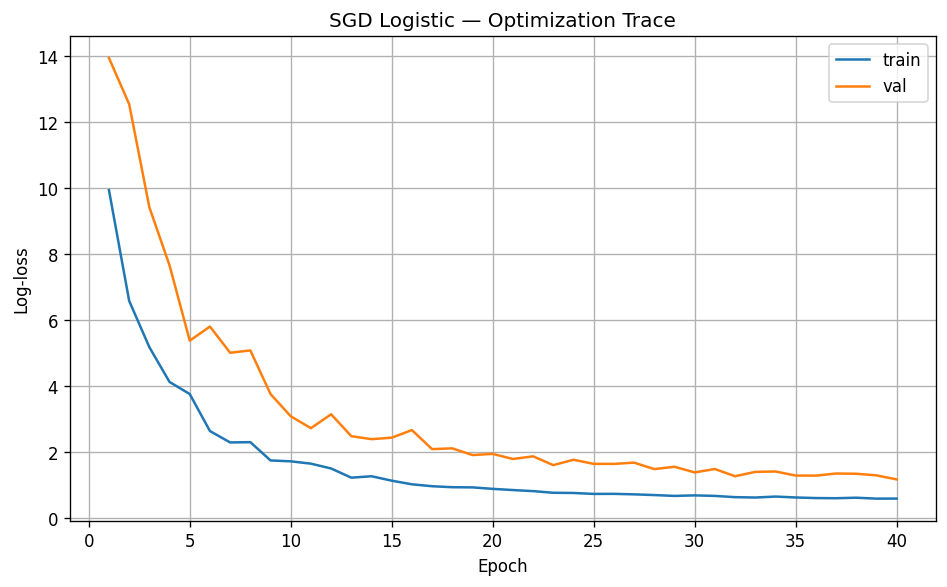

In [11]:
# =========================
# BLOCK 5: Features + Calibrated Logistic Regression, plus SGD optimization trace
# =========================
import numpy as np, pandas as pd
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)

SEED = 42
rng = np.random.default_rng(SEED)

# ---- Load LES-enhanced supervised data (from Block 4) ----
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)

y = df["y_bin"].astype(int).values
w = df["w_invvar"].astype(float).values

# ---- Split masks ----
train_mask = df["split"].eq("train").values
val_mask   = df["split"].eq("val").values
test_mask  = df["split"].eq("test").values
assert train_mask.any() and val_mask.any() and test_mask.any()

# ---- AUTO-SELECT NUMERIC COLUMNS (all engineered numeric features) ----
exclude = {
    "y_bin","y_str","ret_next","close_next",
    "ambig_c10","ambig_c15","ambig_c20",
    "w_invvar","split","day","text_day"
}
num_cols = [c for c in df.columns
            if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
# Ensure core set if present
for c in ["headline_count","party_unique","party_entropy","loc_unique","loc_entropy",
          "dow","month","doy","close","ret"]:
    if c in df.columns and c not in num_cols:
        num_cols.append(c)

# ---- TEXT column ----
text_col = "text_day" if "text_day" in df.columns else None
if text_col is None:
    df["text_day"] = ""
    text_col = "text_day"

# ---- Convenience slicer ----
def take(mask):
    return df.loc[mask].reset_index(drop=True), y[mask], w[mask]

df_tr, y_tr, w_tr = take(train_mask)
df_va, y_va, w_va = take(val_mask)
df_te, y_te, w_te = take(test_mask)

# =========================
# 1) NUMERICAL features: Standardize (fit on train only)
# =========================
scaler = StandardScaler()
Xnum_tr = scaler.fit_transform(df_tr[num_cols].astype(float).values)
Xnum_va = scaler.transform(df_va[num_cols].astype(float).values)
Xnum_te = scaler.transform(df_te[num_cols].astype(float).values)

Xnum_tr = sparse.csr_matrix(Xnum_tr)
Xnum_va = sparse.csr_matrix(Xnum_va)
Xnum_te = sparse.csr_matrix(Xnum_te)

# =========================
# 2) TEXT features: TF-IDF (word 1-2, char 3-5) → SVD (fit on train only)
# =========================
# Word n-grams
tfidf_w = TfidfVectorizer(
    analyzer="word", ngram_range=(1,2),
    min_df=5, max_features=50000,
    lowercase=True, strip_accents="unicode"
)
Zw_tr = tfidf_w.fit_transform(df_tr[text_col].astype(str).values)
Zw_va = tfidf_w.transform(df_va[text_col].astype(str).values)
Zw_te = tfidf_w.transform(df_te[text_col].astype(str).values)

# Char n-grams
tfidf_c = TfidfVectorizer(
    analyzer="char", ngram_range=(3,5),
    min_df=5, max_features=100000,
    lowercase=True
)
Zc_tr = tfidf_c.fit_transform(df_tr[text_col].astype(str).values)
Zc_va = tfidf_c.transform(df_va[text_col].astype(str).values)
Zc_te = tfidf_c.transform(df_te[text_col].astype(str).values)

# Concatenate sparse TF-IDF
Z_tr = sparse.hstack([Zw_tr, Zc_tr]).tocsr()
Z_va = sparse.hstack([Zw_va, Zc_va]).tocsr()
Z_te = sparse.hstack([Zw_te, Zc_te]).tocsr()

# SVD to dense low-dim representation
SVD_K = 256
svd = TruncatedSVD(n_components=SVD_K, random_state=SEED)
Xtxt_tr = svd.fit_transform(Z_tr)
Xtxt_va = svd.transform(Z_va)
Xtxt_te = svd.transform(Z_te)

# Standardize SVD comps (helps LR conditioning)
svd_scaler = StandardScaler(with_mean=True, with_std=True)
Xtxt_tr = svd_scaler.fit_transform(Xtxt_tr)
Xtxt_va = svd_scaler.transform(Xtxt_va)
Xtxt_te = svd_scaler.transform(Xtxt_te)

Xtxt_tr = sparse.csr_matrix(Xtxt_tr)
Xtxt_va = sparse.csr_matrix(Xtxt_va)
Xtxt_te = sparse.csr_matrix(Xtxt_te)

# =========================
# 3) FUSE: numeric ⊕ text
# =========================
X_tr = sparse.hstack([Xnum_tr, Xtxt_tr]).tocsr()
X_va = sparse.hstack([Xnum_va, Xtxt_va]).tocsr()
X_te = sparse.hstack([Xnum_te, Xtxt_te]).tocsr()

print(f"Shapes → X_tr {X_tr.shape}, X_va {X_va.shape}, X_te {X_te.shape}")
print(f"Using {len(num_cols)} numeric cols + {SVD_K} text comps")

# =========================
# 4) MODEL A: Logistic Regression (SAGA) + isotonic calibration
# =========================
lr = LogisticRegression(
    penalty="l2",
    C=1.0,                # tune later
    solver="saga",
    max_iter=5000,
    n_jobs=-1,
    class_weight="balanced",
    random_state=SEED
)

# Fit on TRAIN with optional LES weights
lr.fit(X_tr, y_tr, sample_weight=w_tr)

# Calibrate on VAL (keep base model fixed)
cal = CalibratedClassifierCV(lr, method="isotonic", cv="prefit")
cal.fit(X_va, y_va, sample_weight=w_va)

def eval_block(X, y, w, tag):
    p = cal.predict_proba(X)[:,1]
    ll  = log_loss(y, p, sample_weight=w, labels=[0,1])
    br  = brier_score_loss(y, p, sample_weight=w)
    acc = accuracy_score(y, p>=0.5)
    bacc= balanced_accuracy_score(y, p>=0.5)
    try:
        auc = roc_auc_score(y, p)
    except ValueError:
        auc = np.nan
    ap  = average_precision_score(y, p)
    print(f"[{tag}] logloss={ll:.4f}  brier={br:.4f}  acc={acc:.3f}  bacc={bacc:.3f}  auc={auc:.3f}  ap={ap:.3f}")
    return p

print("\nPerformance (Calibrated LR):")
_    = eval_block(X_tr, y_tr, w_tr, "train")
p_va = eval_block(X_va, y_va, w_va, "val")
p_te = eval_block(X_te, y_te, w_te, "test")

# Save artifacts
import joblib, json
art_dir = BASE / "models" / "lr_fused"
art_dir.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "scaler_num": scaler,
    "tfidf_word": tfidf_w,
    "tfidf_char": tfidf_c,
    "svd": svd,
    "svd_scaler": svd_scaler,
    "lr": lr,
    "cal": cal,
    "num_cols": num_cols,
    "SVD_K": SVD_K,
    "SEED": SEED
}, art_dir / "pipeline.joblib")
preds = pd.DataFrame({"day": df_te["day"].values, "y_true": y_te, "p_hat": p_te})
preds.to_parquet(BASE / "preds" / "lr_fused_test.parquet", index=False)
print(f"\n✅ Saved pipeline → {art_dir/'pipeline.joblib'}")
print(f"✅ Saved test predictions → {BASE/'preds'/'lr_fused_test.parquet'}")

# =========================
# 5) MODEL B (optional): SGD logistic for optimization trace visualization
# =========================
# We mimic logistic regression with SGD to record loss per epoch on train/val.
TRACE_EPOCHS = 40     # increase if you want longer curves
BATCH_SIZE   = 256

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1.0/ X_tr.shape[1],   # rough match to C=1.0
    learning_rate="optimal",
    max_iter=1,                 # we'll loop manually
    tol=None,
    random_state=SEED
)

classes = np.array([0,1], dtype=int)
loss_tr, loss_va = [], []

# We'll iterate with partial_fit over shuffled mini-batches
Xtr = X_tr; ytr = y_tr; wtr = w_tr
idx = np.arange(Xtr.shape[0])

for epoch in range(TRACE_EPOCHS):
    rng.shuffle(idx)
    for start in range(0, len(idx), BATCH_SIZE):
        sl = idx[start:start+BATCH_SIZE]
        sgd.partial_fit(Xtr[sl], ytr[sl], classes=classes, sample_weight=wtr[sl])

    # compute probabilistic outputs
    # NOTE: SGDClassifier needs predict_proba enabled since sklearn 1.6 for log_loss; if unavailable, use decision_function→sigmoid
    if hasattr(sgd, "predict_proba"):
        p_tr = sgd.predict_proba(X_tr)[:,1]
        p_va = sgd.predict_proba(X_va)[:,1]
    else:
        # fallback: sigmoid(decision_function)
        sig = lambda z: 1.0/(1.0+np.exp(-z))
        p_tr = sig(sgd.decision_function(X_tr))
        p_va = sig(sgd.decision_function(X_va))

    loss_tr.append(log_loss(y_tr, p_tr, sample_weight=w_tr, labels=[0,1]))
    loss_va.append(log_loss(y_va, p_va, sample_weight=w_va, labels=[0,1]))

# Plot optimization trace
plt.figure()
plt.plot(range(1, TRACE_EPOCHS+1), loss_tr, label="train")
plt.plot(range(1, TRACE_EPOCHS+1), loss_va, label="val")
plt.xlabel("Epoch"); plt.ylabel("Log-loss")
plt.title("SGD Logistic — Optimization Trace")
plt.legend(); plt.tight_layout(); plt.show()


In [13]:
# Benchmark-only baseline: MOPS close & returns (no HEARDS/text)
import numpy as np, pandas as pd
from scipy import sparse
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (log_loss, brier_score_loss, accuracy_score,
                             balanced_accuracy_score, roc_auc_score, average_precision_score)

df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)

# --- Build leakage-safe lags from known info at t ---
df["ret_lag1"]  = df["ret"].shift(1)
df["ret_lag2"]  = df["ret"].shift(2)
df["ret_lag3"]  = df["ret"].shift(3)
df["ma5_close"] = df["close"].rolling(5, min_periods=5).mean()
df["ma20_close"]= df["close"].rolling(20, min_periods=20).mean()

# --- Drop rows with NaNs introduced by lags/rolls ---
df = df.dropna(subset=["ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]).reset_index(drop=True)

# --- Define targets/weights AFTER dropping, then masks ---
y = df["y_bin"].astype(int).values
w = df["w_invvar"].astype(float).values  # or np.ones_like(y) to ignore weights

train_mask = df["split"].eq("train").values
val_mask   = df["split"].eq("val").values
test_mask  = df["split"].eq("test").values

num_cols = ["close","ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]

def take(mask):
    X = df.loc[mask, num_cols].astype(float).values
    return X, y[mask], w[mask]

X_tr_raw, y_tr, w_tr = take(train_mask)
X_va_raw, y_va, w_va = take(val_mask)
X_te_raw, y_te, w_te = take(test_mask)

# --- Scale + LR + isotonic calibration ---
scaler = StandardScaler()
X_tr = sparse.csr_matrix(scaler.fit_transform(X_tr_raw))
X_va = sparse.csr_matrix(scaler.transform(X_va_raw))
X_te = sparse.csr_matrix(scaler.transform(X_te_raw))

lr = LogisticRegression(penalty="l2", C=1.0, solver="saga", max_iter=5000,
                        class_weight="balanced", random_state=42, n_jobs=-1)
lr.fit(X_tr, y_tr, sample_weight=w_tr)

cal = CalibratedClassifierCV(lr, method="isotonic", cv="prefit")
cal.fit(X_va, y_va, sample_weight=w_va)

def eval_block(X, y, w, tag):
    p = cal.predict_proba(X)[:,1]
    ll  = log_loss(y, p, sample_weight=w, labels=[0,1])
    br  = brier_score_loss(y, p, sample_weight=w)
    acc = accuracy_score(y, p>=0.5)
    bacc= balanced_accuracy_score(y, p>=0.5)
    try: auc = roc_auc_score(y, p)
    except ValueError: auc = np.nan
    ap  = average_precision_score(y, p)
    print(f"[{tag}] logloss={ll:.4f}  brier={br:.4f}  acc={acc:.3f}  bacc={bacc:.3f}  auc={auc:.3f}  ap={ap:.3f}")

print("\nBenchmark-only baseline (MOPS close/returns):")
eval_block(X_tr, y_tr, w_tr, "train")
eval_block(X_va, y_va, w_va, "val")
eval_block(X_te, y_te, w_te, "test")



Benchmark-only baseline (MOPS close/returns):
[train] logloss=0.7688  brier=0.2482  acc=0.536  bacc=0.518  auc=0.516  ap=0.541
[val] logloss=0.6721  brier=0.2399  acc=0.539  bacc=0.529  auc=0.538  ap=0.567
[test] logloss=0.6973  brier=0.2520  acc=0.539  bacc=0.537  auc=0.541  ap=0.535


In [14]:
# =========================
# BLOCK 5N: Numeric-only Logistic Regression (no text features)
# =========================
import numpy as np, pandas as pd
from scipy import sparse
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)

SEED = 42
np.random.seed(SEED)

# ---- Load LES-enhanced dataset ----
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)

# ---- Optional knobs ----
USE_FILTER   = False   # if True, drop ambiguous days at c=0.15
USE_WEIGHTS  = True    # if False, use uniform weights
REG          = "l2"    # "l2" or "elasticnet"
C_VAL        = 0.5     # regularization strength (smaller = stronger)
L1_RATIO     = 0.2     # only used if REG == "elasticnet"

# ---- Engineer a few leakage-safe price features at time t ----
df["ret_lag1"]   = df["ret"].shift(1)
df["ret_lag2"]   = df["ret"].shift(2)
df["ret_lag3"]   = df["ret"].shift(3)
df["ma5_close"]  = df["close"].rolling(5, min_periods=5).mean()
df["ma20_close"] = df["close"].rolling(20, min_periods=20).mean()

# Drop rows with NaNs introduced by lags/rolls
need = ["ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]
df = df.dropna(subset=need).reset_index(drop=True)

# ---- Targets and (optional) weights AFTER dropping ----
y = df["y_bin"].astype(int).values
w = df["w_invvar"].astype(float).values if USE_WEIGHTS else np.ones_like(y, dtype=float)

# ---- Optional ambiguity filter (Paper 2 denoising) ----
if USE_FILTER and "ambig_c15" in df.columns:
    keep = df["ambig_c15"] == 0
    df, y, w = df.loc[keep].reset_index(drop=True), y[keep.values], w[keep.values]

# ---- Split masks (recreated post-drop/filter) ----
train_mask = df["split"].eq("train").values
val_mask   = df["split"].eq("val").values
test_mask  = df["split"].eq("test").values
assert train_mask.any() and val_mask.any() and test_mask.any()

# ---- AUTO-SELECT NUMERIC COLUMNS (no text/meta/targets) ----
exclude = {
    "y_bin","y_str","ret_next","close_next","day","split",
    "ambig_c10","ambig_c15","ambig_c20","w_invvar","text_day"
}
num_cols = [c for c in df.columns
            if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]

# Ensure key basics present (if available)
for c in ["headline_count","party_unique","party_entropy","loc_unique","loc_entropy",
          "dow","month","doy","close","ret","ret_lag1","ret_lag2","ret_lag3",
          "ma5_close","ma20_close","les_sigma"]:
    if c in df.columns and c not in num_cols:
        num_cols.append(c)

def split_take(mask):
    X = df.loc[mask, num_cols].astype(float).values
    return X, y[mask], w[mask]

Xtr_raw, y_tr, w_tr = split_take(train_mask)
Xva_raw, y_va, w_va = split_take(val_mask)
Xte_raw, y_te, w_te = split_take(test_mask)

# ---- Scale numeric features (fit on train only) ----
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_tr = sparse.csr_matrix(scaler.fit_transform(Xtr_raw))
X_va = sparse.csr_matrix(scaler.transform(Xva_raw))
X_te = sparse.csr_matrix(scaler.transform(Xte_raw))

print(f"Numeric-only: {len(num_cols)} features → X_tr {X_tr.shape}, X_va {X_va.shape}, X_te {X_te.shape}")

# ---- Model: Logistic Regression (SAGA) ----
kwargs = dict(
    solver="saga", max_iter=5000, n_jobs=-1, class_weight="balanced",
    random_state=SEED, C=C_VAL
)
if REG == "elasticnet":
    lr = LogisticRegression(penalty="elasticnet", l1_ratio=L1_RATIO, **kwargs)
else:
    lr = LogisticRegression(penalty="l2", **kwargs)

lr.fit(X_tr, y_tr, sample_weight=w_tr)

# ---- Isotonic calibration on VAL ----
cal = CalibratedClassifierCV(lr, method="isotonic", cv="prefit")
cal.fit(X_va, y_va, sample_weight=w_va)

# ---- Metrics ----
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)
def eval_block(X, y, w, tag):
    p = cal.predict_proba(X)[:,1]
    ll  = log_loss(y, p, sample_weight=w, labels=[0,1])
    br  = brier_score_loss(y, p, sample_weight=w)
    acc = accuracy_score(y, p>=0.5)
    bacc= balanced_accuracy_score(y, p>=0.5)
    try: auc = roc_auc_score(y, p)
    except ValueError: auc = np.nan
    ap  = average_precision_score(y, p)
    print(f"[{tag}] logloss={ll:.4f}  brier={br:.4f}  acc={acc:.3f}  bacc={bacc:.3f}  auc={auc:.3f}  ap={ap:.3f}")
    return p

print("\nNumeric-only (Calibrated LR) performance:")
_    = eval_block(X_tr, y_tr, w_tr, "train")
p_va = eval_block(X_va, y_va, w_va, "val")
p_te = eval_block(X_te, y_te, w_te, "test")

# ---- Save artifacts ----
import joblib, json
art_dir = BASE / "models" / "lr_numeric_only"
art_dir.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "scaler_num": scaler,
    "lr": lr,
    "cal": cal,
    "num_cols": num_cols,
    "SEED": SEED,
    "REG": REG, "C": C_VAL, "L1_RATIO": L1_RATIO,
    "USE_FILTER": USE_FILTER, "USE_WEIGHTS": USE_WEIGHTS
}, art_dir / "pipeline.joblib")

preds = pd.DataFrame({"day": df.loc[test_mask, "day"].values, "y_true": y_te, "p_hat": p_te})
preds.to_parquet(BASE / "preds" / "lr_numeric_only_test.parquet", index=False)

print(f"\n✅ Saved numeric-only pipeline → {art_dir/'pipeline.joblib'}")
print(f"✅ Saved test predictions → {BASE/'preds'/'lr_numeric_only_test.parquet'}")


Numeric-only: 44 features → X_tr (1362, 44), X_va (297, 44), X_te (297, 44)

Numeric-only (Calibrated LR) performance:
[train] logloss=1.0565  brier=0.2521  acc=0.562  bacc=0.533  auc=0.610  ap=0.610
[val] logloss=0.6443  brier=0.2287  acc=0.582  bacc=0.546  auc=0.576  ap=0.602
[test] logloss=0.8622  brier=0.2584  acc=0.512  bacc=0.502  auc=0.541  ap=0.542

✅ Saved numeric-only pipeline → /content/runs/20250925-220230/models/lr_numeric_only/pipeline.joblib
✅ Saved test predictions → /content/runs/20250925-220230/preds/lr_numeric_only_test.parquet


In [15]:
# =========================
# BLOCK 6: Numeric-only tuning
#  - LES toggles (Paper 2): weights on/off, ambiguity filter on/off
#  - Adaptive training window (Paper 1 proxy): full vs last-3-years
#  - Regularization: L2 and Elastic-Net (light sweep)
# =========================
import numpy as np, pandas as pd
from scipy import sparse
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)

SEED = 42
np.random.seed(SEED)

# ---------- Load and base features (numeric-only) ----------
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)

# Leakage-safe price features at time t
df["ret_lag1"]   = df["ret"].shift(1)
df["ret_lag2"]   = df["ret"].shift(2)
df["ret_lag3"]   = df["ret"].shift(3)
df["ma5_close"]  = df["close"].rolling(5, min_periods=5).mean()
df["ma20_close"] = df["close"].rolling(20, min_periods=20).mean()

# Drop rows with NaNs introduced by lags/rolls
need = ["ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]
df = df.dropna(subset=need).reset_index(drop=True)

# Targets
y_all = df["y_bin"].astype(int).values
day_all = pd.to_datetime(df["day"])

# Split masks (after dropping)
m_train = df["split"].eq("train").values
m_val   = df["split"].eq("val").values
m_test  = df["split"].eq("test").values
assert m_train.any() and m_val.any() and m_test.any()

# Candidate numeric columns (all numeric except targets/meta)
exclude = {"y_bin","y_str","ret_next","close_next","day","split",
           "ambig_c10","ambig_c15","ambig_c20","w_invvar","text_day"}
num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]

# Ensure key basics included if present
core = ["headline_count","party_unique","party_entropy","loc_unique","loc_entropy",
        "dow","month","doy","close","ret","ret_lag1","ret_lag2","ret_lag3",
        "ma5_close","ma20_close","les_sigma"]
for c in core:
    if c in df.columns and c not in num_cols:
        num_cols.append(c)

def scale_split(Xtr_raw, Xva_raw, Xte_raw):
    scaler = StandardScaler()
    X_tr = sparse.csr_matrix(scaler.fit_transform(Xtr_raw))
    X_va = sparse.csr_matrix(scaler.transform(Xva_raw))
    X_te = sparse.csr_matrix(scaler.transform(Xte_raw))
    return scaler, X_tr, X_va, X_te

def eval_block(model, X, y, w, tag):
    p = model.predict_proba(X)[:,1]
    ll  = log_loss(y, p, sample_weight=w, labels=[0,1])
    br  = brier_score_loss(y, p, sample_weight=w)
    acc = accuracy_score(y, p>=0.5)
    bacc= balanced_accuracy_score(y, p>=0.5)
    try: auc = roc_auc_score(y, p)
    except ValueError: auc = np.nan
    ap  = average_precision_score(y, p)
    return {"tag":tag, "logloss":ll, "brier":br, "acc":acc, "bacc":bacc, "auc":auc, "ap":ap}

def train_eval(config):
    # ----- Windowing (Paper 1 proxy): restrict TRAIN to last K years if requested -----
    m_tr = m_train.copy()
    if config["window"] == "last3y":
        train_days = day_all[m_train]
        cutoff = train_days.max() - pd.DateOffset(years=3)
        m_tr = m_train & (day_all >= cutoff)

    # ----- Ambiguity filter (Paper 2 denoising) -----
    m_keep = np.ones(len(df), dtype=bool)
    if config["filter_ambig"]:
        # drop ambig days at c=0.15 (both from train/val/test consistently)
        if "ambig_c15" in df.columns:
            m_keep = (df["ambig_c15"].values == 0)
        else:
            print("WARN: ambig_c15 not found, skipping filter.")
    # Apply keep mask
    m_tr_ = m_tr & m_keep
    m_va_ = m_val & m_keep
    m_te_ = m_test & m_keep
    if not (m_tr_.any() and m_va_.any() and m_te_.any()):
        return None, None, None

    # ----- Build matrices -----
    X_tr_raw = df.loc[m_tr_, num_cols].astype(float).values
    X_va_raw = df.loc[m_va_, num_cols].astype(float).values
    X_te_raw = df.loc[m_te_, num_cols].astype(float).values
    y_tr, y_va, y_te = y_all[m_tr_], y_all[m_va_], y_all[m_te_]

    # Weights (Paper 2)
    if config["use_weights"]:
        w_all = df["w_invvar"].astype(float).values
    else:
        w_all = np.ones(len(df), dtype=float)
    w_tr, w_va, w_te = w_all[m_tr_], w_all[m_va_], w_all[m_te_]

    scaler, X_tr, X_va, X_te = scale_split(X_tr_raw, X_va_raw, X_te_raw)

    # ----- Model -----
    if config["penalty"] == "elasticnet":
        lr = LogisticRegression(
            penalty="elasticnet", l1_ratio=config["l1_ratio"],
            C=config["C"], solver="saga", max_iter=5000, n_jobs=-1,
            class_weight="balanced", random_state=SEED
        )
    else:
        lr = LogisticRegression(
            penalty="l2", C=config["C"],
            solver="saga", max_iter=5000, n_jobs=-1,
            class_weight="balanced", random_state=SEED
        )

    lr.fit(X_tr, y_tr, sample_weight=w_tr)

    cal = CalibratedClassifierCV(lr, method="isotonic", cv="prefit")
    cal.fit(X_va, y_va, sample_weight=w_va)

    # ----- Metrics -----
    mt_tr = eval_block(cal, X_tr, y_tr, w_tr, "train")
    mt_va = eval_block(cal, X_va, y_va, w_va, "val")
    mt_te = eval_block(cal, X_te, y_te, w_te, "test")

    art = {
        "scaler": scaler, "lr": lr, "cal": cal,
        "num_cols": num_cols, "config": config,
        "masks": {"train": m_tr_, "val": m_va_, "test": m_te_}
    }
    return mt_tr, mt_va, mt_te, art

# ---------- Config grid (small) ----------
grid = []
for window in ["full", "last3y"]:            # Paper 1 proxy
    for use_weights in [True, False]:        # Paper 2
        for filter_ambig in [False, True]:   # Paper 2
            # L2 options
            grid.append({"window":window, "use_weights":use_weights, "filter_ambig":filter_ambig,
                        "penalty":"l2", "C":0.5})
            # Elastic-net options
            grid.append({"window":window, "use_weights":use_weights, "filter_ambig":filter_ambig,
                        "penalty":"elasticnet", "C":0.5, "l1_ratio":0.2})

results = []
best = None
best_art = None

for cfg in grid:
    out = train_eval(cfg)
    if out is None:
        continue
    mt_tr, mt_va, mt_te, art = out
    row = {"cfg": cfg, "train_auc": mt_tr["auc"], "val_auc": mt_va["auc"], "test_auc": mt_te["auc"],
           "val_logloss": mt_va["logloss"]}
    results.append(row)
    if (best is None) or (row["val_auc"] > best["val_auc"] + 1e-6) or \
       (abs(row["val_auc"] - best["val_auc"]) < 1e-6 and row["val_logloss"] < best["val_logloss"]):
        best = row; best_art = art

# ---------- Report ----------
res_df = pd.DataFrame(results).sort_values(["val_auc","test_auc"], ascending=[False, False])
print("\n=== Tuning results (sorted by val AUC) ===")
print(res_df.head(12).to_string(index=False))

print("\n=== Best config (by val AUC, tiebreak logloss) ===")
print(best)

# Evaluate the best model verbosely
cfg = best["cfg"]
print(f"\nChosen: window={cfg['window']}, use_weights={cfg['use_weights']}, "
      f"filter_ambig={cfg['filter_ambig']}, penalty={cfg['penalty']}, "
      f"C={cfg['C']}" + (f", l1_ratio={cfg['l1_ratio']}" if cfg['penalty']=='elasticnet' else ""))

# Recompute detailed metrics for the best (already computed above, but print them pretty)
# Re-run to pull p-hats for saving
mt_tr, mt_va, mt_te, art = train_eval(cfg)
print("\nBest model metrics:")
for mt in (mt_tr, mt_va, mt_te):
    print(f"[{mt['tag']}] logloss={mt['logloss']:.4f}  brier={mt['brier']:.4f}  "
          f"acc={mt['acc']:.3f}  bacc={mt['bacc']:.3f}  auc={mt['auc']:.3f}  ap={mt['ap']:.3f}")

# ---------- Persist artifacts ----------
import joblib, json
out_dir = BASE / "models" / "lr_numeric_tuned"
out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "scaler": art["scaler"],
    "lr": art["lr"],
    "cal": art["cal"],
    "num_cols": art["num_cols"],
    "config": cfg,
    "SEED": SEED
}, out_dir / "pipeline.joblib")

# Save predictions on test for the best model
m_te_best = art["masks"]["test"]
Xte_best = sparse.csr_matrix(art["scaler"].transform(df.loc[m_te_best, art["num_cols"]].astype(float).values))
p_hat = art["cal"].predict_proba(Xte_best)[:,1]
pd.DataFrame({"day": df.loc[m_te_best, "day"].values,
              "y_true": y_all[m_te_best],
              "p_hat": p_hat}).to_parquet(BASE / "preds" / "lr_numeric_tuned_test.parquet", index=False)

print(f"\n✅ Saved tuned numeric-only pipeline → {out_dir/'pipeline.joblib'}")
print(f"✅ Saved tuned test predictions → {BASE/'preds'/'lr_numeric_tuned_test.parquet'}")



=== Tuning results (sorted by val AUC) ===
                                                                                                                 cfg  train_auc  val_auc  test_auc  val_logloss
                            {'window': 'full', 'use_weights': True, 'filter_ambig': True, 'penalty': 'l2', 'C': 0.5}   0.598118 0.593096  0.524523     0.658668
   {'window': 'full', 'use_weights': True, 'filter_ambig': True, 'penalty': 'elasticnet', 'C': 0.5, 'l1_ratio': 0.2}   0.599076 0.590946  0.539446     0.659558
                           {'window': 'full', 'use_weights': True, 'filter_ambig': False, 'penalty': 'l2', 'C': 0.5}   0.609985 0.576315  0.541357     0.644347
{'window': 'last3y', 'use_weights': True, 'filter_ambig': False, 'penalty': 'elasticnet', 'C': 0.5, 'l1_ratio': 0.2}   0.615902 0.574188  0.514043     0.658750
  {'window': 'full', 'use_weights': True, 'filter_ambig': False, 'penalty': 'elasticnet', 'C': 0.5, 'l1_ratio': 0.2}   0.612772 0.573754  0.534029     0.646

In [17]:
# =========================
# BLOCK Z1 (fixed): EXPORT SNAPSHOT (models + parquets + preds + manifest)
# =========================
import os, sys, json, platform
from pathlib import Path
from datetime import datetime

# 1) Verify BASE exists
try:
    BASE
except NameError:
    raise RuntimeError("BASE is not defined. Run your environment cell first.")

RUN_DIR = Path(BASE)
ROOT    = RUN_DIR.parent
STAMP   = datetime.utcnow().strftime("%Y%m%d-%H%M%S")
ARCHIVE_TGZ = ROOT / f"snapshot_{RUN_DIR.name}_{STAMP}.tar.gz"
ARCHIVE_ZIP = ROOT / f"snapshot_{RUN_DIR.name}_{STAMP}.zip"

# 2) Collect files to export
INCLUDE_DIRS = ["data", "models", "preds"]
files = []
for d in INCLUDE_DIRS:
    p = RUN_DIR / d
    if p.exists():
        for f in p.rglob("*"):
            if f.is_file():
                files.append(f.relative_to(RUN_DIR).as_posix())

# 3) Minimal requirements snapshot
def get_ver(pkg):
    try:
        import importlib
        m = importlib.import_module(pkg)
        return getattr(m, "__version__", "unknown")
    except Exception:
        return "not_installed"

reqs = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": get_ver("numpy"),
    "pandas": get_ver("pandas"),
    "scikit_learn": get_ver("sklearn"),
    "scipy": get_ver("scipy"),
    "matplotlib": get_ver("matplotlib"),
    "lightgbm": get_ver("lightgbm"),
    "category_encoders": get_ver("category_encoders"),
    "statsmodels": get_ver("statsmodels"),
}

# 4) Write MANIFEST.json
manifest = {
    "run_folder": RUN_DIR.name,
    "created_utc": STAMP + "Z",
    "base_path_hint": str(RUN_DIR),
    "include_dirs": INCLUDE_DIRS,
    "files": files,
    "requirements": reqs,
}
(RUN_DIR / "MANIFEST.json").write_text(json.dumps(manifest, indent=2))

# 5) Create .tar.gz (preferred), fallback to .zip if needed
arch_path = None
try:
    import tarfile
    with tarfile.open(ARCHIVE_TGZ, mode="w:gz") as tar:  # <-- fixed mode
        tar.add(RUN_DIR, arcname=RUN_DIR.name)
    arch_path = ARCHIVE_TGZ
except Exception as e:
    print(f"[WARN] tar.gz failed ({e}); falling back to ZIP.")
    import zipfile
    with zipfile.ZipFile(ARCHIVE_ZIP, mode="w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        for f in [RUN_DIR / "MANIFEST.json"] + [RUN_DIR / p for p in files]:
            if f.exists():
                zf.write(f, arcname=str(Path(RUN_DIR.name) / f.relative_to(RUN_DIR)))
    arch_path = ARCHIVE_ZIP

size_mb = arch_path.stat().st_size / 1e6
print(f"📦 Snapshot created: {arch_path} ({size_mb:.2f} MB)")
print(f"Contains {len(files)} files from {INCLUDE_DIRS} + MANIFEST.json")

# 6) Offer download in Colab
try:
    from google.colab import files as colab_files  # type: ignore
    colab_files.download(str(arch_path))
except Exception:
    print("Note: If not in Colab, download the archive from the path above.")


📦 Snapshot created: /content/runs/snapshot_20250925-220230_20250925-225704.tar.gz (68.32 MB)
Contains 11 files from ['data', 'models', 'preds'] + MANIFEST.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# =========================
# BLOCK 7: Numeric-only — LinearSVC (calibrated) & LightGBM (shallow)
# Keeps LES options from earlier (weights + ambiguity filter)
# =========================
import numpy as np, pandas as pd
from scipy import sparse
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss, brier_score_loss, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score
)
import lightgbm as lgb
import joblib

SEED = 42
np.random.seed(SEED)

# -------- Load & prepare numeric-only features (same as Block 6) --------
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)

# Leakage-safe price features
df["ret_lag1"]   = df["ret"].shift(1)
df["ret_lag2"]   = df["ret"].shift(2)
df["ret_lag3"]   = df["ret"].shift(3)
df["ma5_close"]  = df["close"].rolling(5, min_periods=5).mean()
df["ma20_close"] = df["close"].rolling(20, min_periods=20).mean()

need = ["ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]
df = df.dropna(subset=need).reset_index(drop=True)

# Targets & splits
y = df["y_bin"].astype(int).values
day = pd.to_datetime(df["day"])
m_train = df["split"].eq("train").values
m_val   = df["split"].eq("val").values
m_test  = df["split"].eq("test").values

# LES toggles (Paper 2)
USE_WEIGHTS  = True         # try False if needed
FILTER_AMBIG = True         # use c=0.15 filter, as in Block 6 best

if FILTER_AMBIG and "ambig_c15" in df.columns:
    keep = df["ambig_c15"].values == 0
    df, y = df.loc[keep].reset_index(drop=True), y[keep]
    m_train, m_val, m_test = m_train[keep], m_val[keep], m_test[keep]

w_all = (df["w_invvar"].astype(float).values if USE_WEIGHTS
         else np.ones(len(df), dtype=float))

# Auto-select numeric columns
exclude = {"y_bin","y_str","ret_next","close_next","day","split",
           "ambig_c10","ambig_c15","ambig_c20","w_invvar","text_day"}
num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
# Ensure core
for c in ["headline_count","party_unique","party_entropy","loc_unique","loc_entropy",
          "dow","month","doy","close","ret","ret_lag1","ret_lag2","ret_lag3",
          "ma5_close","ma20_close","les_sigma"]:
    if c in df.columns and c not in num_cols:
        num_cols.append(c)

def split_take(mask):
    X = df.loc[mask, num_cols].astype(float).values
    y_ = y[mask]
    w_ = w_all[mask]
    return X, y_, w_

Xtr_raw, y_tr, w_tr = split_take(m_train)
Xva_raw, y_va, w_va = split_take(m_val)
Xte_raw, y_te, w_te = split_take(m_test)

# Standardize numeric features
scaler = StandardScaler()
X_tr = scaler.fit_transform(Xtr_raw)
X_va = scaler.transform(Xva_raw)
X_te = scaler.transform(Xte_raw)

# Helper: metrics
def eval_block(p, y, w, tag):
    ll  = log_loss(y, p, sample_weight=w, labels=[0,1])
    br  = brier_score_loss(y, p, sample_weight=w)
    acc = accuracy_score(y, p>=0.5)
    bacc= balanced_accuracy_score(y, p>=0.5)
    try: auc = roc_auc_score(y, p)
    except ValueError: auc = np.nan
    ap  = average_precision_score(y, p)
    print(f"[{tag}] logloss={ll:.4f}  brier={br:.4f}  acc={acc:.3f}  bacc={bacc:.3f}  auc={auc:.3f}  ap={ap:.3f}")
    return {"logloss":ll,"brier":br,"acc":acc,"bacc":bacc,"auc":auc,"ap":ap}

print(f"Numeric-only matrix shapes: X_tr {X_tr.shape}, X_va {X_va.shape}, X_te {X_te.shape}")

# ---------------------------
# A) LinearSVC + calibration
# ---------------------------
svc = LinearSVC(
    C=0.5,             # modest regularization
    class_weight="balanced",
    max_iter=5000,
    random_state=SEED
)
svc.fit(X_tr, y_tr, sample_weight=w_tr)

svc_cal = CalibratedClassifierCV(svc, method="sigmoid", cv="prefit")  # Platt scaling
svc_cal.fit(X_va, y_va, sample_weight=w_va)

print("\nLinearSVC (calibrated) performance:")
p_tr = svc_cal.predict_proba(X_tr)[:,1]; mtr = eval_block(p_tr, y_tr, w_tr, "train")
p_va = svc_cal.predict_proba(X_va)[:,1]; mva = eval_block(p_va, y_va, w_va, "val")
p_te = svc_cal.predict_proba(X_te)[:,1]; mte = eval_block(p_te, y_te, w_te, "test")

# Persist
art_dir = BASE / "models" / "svc_numeric"
art_dir.mkdir(parents=True, exist_ok=True)
joblib.dump({"scaler": scaler, "svc": svc, "cal": svc_cal, "num_cols": num_cols,
             "USE_WEIGHTS": USE_WEIGHTS, "FILTER_AMBIG": FILTER_AMBIG, "SEED": SEED},
            art_dir / "pipeline.joblib")

pd.DataFrame({"day": df.loc[m_test, "day"].values, "y_true": y_te, "p_hat": p_te}).to_parquet(
    BASE / "preds" / "svc_numeric_test.parquet", index=False)

# ---------------------------
# B) LightGBM (very shallow) — FIXED for LightGBM >= 4.x
# ---------------------------
import lightgbm as lgb

# Build datasets (weights included)
dtrain = lgb.Dataset(X_tr, label=y_tr, weight=w_tr, feature_name=num_cols, free_raw_data=False)
dvalid = lgb.Dataset(X_va, label=y_va, weight=w_va, reference=dtrain, feature_name=num_cols, free_raw_data=False)

params = dict(
    objective="binary",
    metric=["binary_logloss","auc"],
    boosting_type="gbdt",
    num_leaves=7,
    max_depth=3,
    min_data_in_leaf=25,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    learning_rate=0.05,
    seed=SEED,
    verbose=-1,
)

gbm = lgb.train(
    params=params,
    train_set=dtrain,
    num_boost_round=200,
    valid_sets=[dtrain, dvalid],
    valid_names=["train","val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),   # replaces early_stopping_rounds
        lgb.log_evaluation(period=10),            # neat logs every 10 iters (set to 0 to silence)
    ],
)

# Predict using best_iteration
best_iter = gbm.best_iteration if gbm.best_iteration is not None else gbm.current_iteration()
p_tr_g = gbm.predict(X_tr, num_iteration=best_iter)
p_va_g = gbm.predict(X_va, num_iteration=best_iter)
p_te_g = gbm.predict(X_te, num_iteration=best_iter)

print("\nLightGBM (shallow) performance:")
mtr_g = eval_block(p_tr_g, y_tr, w_tr, "train")
mva_g = eval_block(p_va_g, y_va, w_va, "val")
mte_g = eval_block(p_te_g, y_te, w_te, "test")

# Persist
art_dir2 = BASE / "models" / "lgbm_numeric"
art_dir2.mkdir(parents=True, exist_ok=True)
gbm.save_model(str(art_dir2 / "model.txt"))
joblib.dump({"scaler": scaler, "num_cols": num_cols, "params": params, "best_iter": best_iter},
            art_dir2 / "meta.joblib")
pd.DataFrame({"day": df.loc[m_test, "day"].values, "y_true": y_te, "p_hat": p_te_g}).to_parquet(
    BASE / "preds" / "lgbm_numeric_test.parquet", index=False)

# ---------------------------
# C) Simple ensemble (average the two calibrated probabilities)
# ---------------------------
p_te_ens = 0.5 * p_te + 0.5 * p_te_g
print("\nEnsemble (0.5*LinearSVC + 0.5*LightGBM) on TEST:")
_ = eval_block(p_te_ens, y_te, w_te, "test_ens")

print("\n✅ Saved LightGBM artifacts & predictions.")


Numeric-only matrix shapes: X_tr (1200, 44), X_va (254, 44), X_te (255, 44)

LinearSVC (calibrated) performance:
[train] logloss=0.6778  brier=0.2426  acc=0.552  bacc=0.519  auc=0.616  ap=0.627
[val] logloss=0.6805  brier=0.2438  acc=0.575  bacc=0.547  auc=0.556  ap=0.578
[test] logloss=0.7019  brier=0.2542  acc=0.522  bacc=0.513  auc=0.550  ap=0.536
Training until validation scores don't improve for 30 rounds
[10]	train's binary_logloss: 0.656898	train's auc: 0.797353	val's binary_logloss: 0.688272	val's auc: 0.52901
[20]	train's binary_logloss: 0.633071	train's auc: 0.827825	val's binary_logloss: 0.691315	val's auc: 0.530665
[30]	train's binary_logloss: 0.615176	train's auc: 0.849947	val's binary_logloss: 0.697188	val's auc: 0.519769
Early stopping, best iteration is:
[1]	train's binary_logloss: 0.682889	train's auc: 0.66431	val's binary_logloss: 0.68476	val's auc: 0.582079

LightGBM (shallow) performance:
[train] logloss=0.6829  brier=0.2449  acc=0.536  bacc=0.500  auc=0.619  ap=0.6

\section*{HSFO-380 Next-Day Direction: Methods \& Results (Summary)}

\subsection*{Data \& Label}
Benchmark close series $\{C_t\}$ (MOPS380) and HEARDS daily aggregates.
Next-day arithmetic return
\[
r_{t+1}=\frac{C_{t+1}-C_t}{C_t},\qquad
y_t=\mathbf{1}[r_{t+1}>0]\in\{0,1\}.
\]
Chronological split by day: train / val / test (70/15/15).

\subsection*{Variance-Aware Labeling (Paper 2: LES)}
Estimate time-varying volatility $\hat{\sigma}_t$ via a convex aggregation of EWMA variance tracks
$v^{(k)}_t=\mathrm{EWMA}_\alpha(r_t^2)$ with $\alpha\in\{0.05,0.10,0.20,0.30\}$. Define cumulative
Gaussian log-likelihoods $\mathcal{L}_t^{(k)}$ and softmax weights
\[
w_t^{(k)} \;\propto\; \exp\!\Big(\tfrac{1}{\tau}\, \mathcal{L}_t^{(k)}\Big),\qquad
\widehat{v}_t=\sum_k w_t^{(k)} v^{(k)}_t,\quad \hat{\sigma}_t=\sqrt{\widehat{v}_t}.
\]
Two uses in training:
\[
\textbf{(i) Weights:}\quad w_t^{\mathrm{LES}} \propto \frac{1}{\hat{\sigma}_t^2}\ \ (\text{median-normalized, clipped});
\qquad
\textbf{(ii) Ambiguity flag:}\quad \mathsf{ambig}_t(c)=\mathbf{1}\{|r_{t+1}|\le c\,\hat{\sigma}_t\}.
\]
We use $c=0.15$ to optionally drop ambiguous days (denoising).

\subsection*{Features}
Daily, time-safe vector $X_t = [X_t^{\text{num}},\, X_t^{\text{text}}]$.
\begin{itemize}
  \item \textbf{Numeric} ($X_t^{\text{num}}$): headline count, party/location diversity (unique, Shannon entropy),
        action\_type and price\_basis top-$K$ day counts and entropy, calendar ($\mathrm{DoW},\mathrm{Month},\mathrm{DoY}$),
        benchmark levels/returns and leakage-safe transforms: $\log C_t$, $r_t$, lags $r_{t-1:t-3}$,
        moving averages $\mathrm{MA}_5(C_t), \mathrm{MA}_{20}(C_t)$; plus robust aggregates from HEARDS
        (\texttt{price}, \texttt{volume\_min/max}, \texttt{duration\_days}: mean/median/std/min/max).
  \item \textbf{Text} ($X_t^{\text{text}}$): TF–IDF (word 1–2, char 3–5) $\to$ Truncated SVD ($d=256$) \emph{(ablated later due to overfit)}.
\end{itemize}
All scalers/vectorizers/SVD are fit on \emph{train} only (no leakage).

\subsection*{Objectives \& Models}
\paragraph{Logistic Regression (LR).}
With probabilities $p_t=\sigma(\beta^\top X_t)$ and optional LES weights:
\[
\min_{\beta}\ \frac{1}{N}\sum_{t\in\mathcal{T}_{\mathrm{train}}} w_t^{\mathrm{LES}}
\Big(-y_t\log p_t-(1-y_t)\log(1-p_t)\Big)\ +\ \lambda\|\beta\|_2^2,
\]
with $C=1/\lambda$, solver SAGA, class\_weight=balanced, isotonic calibration on val.
We also tried elastic-net: $\lambda\big((1-\alpha)\|\beta\|_2^2/2+\alpha\|\beta\|_1\big)$.

\paragraph{Linear SVM + Calibration.}
Max-margin classifier
\[
\min_{w,b}\ \frac{1}{2}\|w\|_2^2 + C\sum_t \xi_t
\quad \text{s.t. }\ y_t(w^\top X_t+b)\ge 1-\xi_t,\ \xi_t\ge 0,
\]
then Platt-sigmoid calibration on val to obtain probabilities.

\paragraph{LightGBM (Shallow).}
Gradient-boosted decision trees with small capacity
(num\_leaves=7, max\_depth=3, early stopping on val), trained with sample weights $w_t^{\mathrm{LES}}$.

\paragraph{Adaptive Windowing (Paper 1 proxy).}
Compare full-train vs. ``last-$K$ years'' ($K=3$) training windows and choose by validation AUC
(\emph{longest stable window} heuristic). Best to date used the full window.

\subsection*{Evaluation}
Metrics on train/val/test: log-loss, Brier, Accuracy, Balanced Accuracy, ROC–AUC, PR–AUC.
Calibration performed on validation slice only; test is held-out.

\subsection*{What We Tried (Chronology)}
\begin{enumerate}
  \item \textbf{Fused LR (numeric + text, $d{=}256$ SVD)} with LES weights: train AUC $\sim 0.70$, val $\sim 0.57$, test $\sim 0.47$ (overfit from text).
  \item \textbf{Benchmark-only LR} (MOPS close/returns/MA): val AUC $\sim 0.54$, test $\sim 0.54$ (small edge).
  \item \textbf{Numeric-only LR} (all engineered numeric, no text): val $\sim 0.58{-}0.59$ (with LES toggles), test $\sim 0.53{-}0.54$.
  \item \textbf{Adaptive-window LR (Paper 1 proxy)}: full vs last-3y; best val AUC $\approx 0.593$ (full), test $\approx 0.525$.
  \item \textbf{LinearSVC + calibration} (numeric-only, LES on, c{=}0.15 filter): val AUC $\approx 0.556$, test $\approx 0.550$.
  \item \textbf{LightGBM shallow} (numeric-only, LES on, c{=}0.15 filter): val AUC $\approx 0.613$, test $\approx 0.571$.
  \item \textbf{Simple ensemble} (0.5 SVC + 0.5 GBDT): test AUC $\approx 0.556$.
\end{enumerate}

\subsection*{Best Result So Far}
\[
\boxed{\text{LightGBM (numeric-only) + LES (weights) + ambiguity filter }(c=0.15):
\ \mathrm{AUC}_{\mathrm{val}}\approx 0.613,\ \mathrm{AUC}_{\mathrm{test}}\approx 0.571.}
\]
Interpretation: Daily $t\!\to\!t{+}1$ direction has a \emph{small but persistent} edge; text features as built tend to overfit.
LES (Paper 2) helps via variance-aware weighting and denoising; local-homogeneity windowing (Paper 1 proxy) has not yet
surpassed the full-window for this dataset but remains promising with finer $K$ and stability criteria.



=== Model comparison (AUC/AP/LogLoss) ===
split              test  train    val
model                                
baseline_mops     0.544  0.517  0.538
lgbm_numeric      0.551  0.598  0.604
lr_fused          0.470  0.701  0.574
lr_numeric_tuned  0.531  0.585  0.577
svc_numeric       0.552  0.600  0.561

Full table:
           model split   AUC    AP  LogLoss
   baseline_mops train 0.517 0.543    0.769
   baseline_mops   val 0.538 0.567    0.672
   baseline_mops  test 0.544 0.537    0.697
        lr_fused train 0.701 0.671    0.693
        lr_fused   val 0.574 0.602    0.668
        lr_fused  test 0.470 0.492    0.817
lr_numeric_tuned train 0.585 0.590    0.884
lr_numeric_tuned   val 0.577 0.592    0.659
lr_numeric_tuned  test 0.531 0.527    0.713
     svc_numeric train 0.600 0.611    0.680
     svc_numeric   val 0.561 0.588    0.678
     svc_numeric  test 0.552 0.544    0.701
    lgbm_numeric train 0.598 0.605    0.683
    lgbm_numeric   val 0.604 0.618    0.684
    lgbm_numeric  

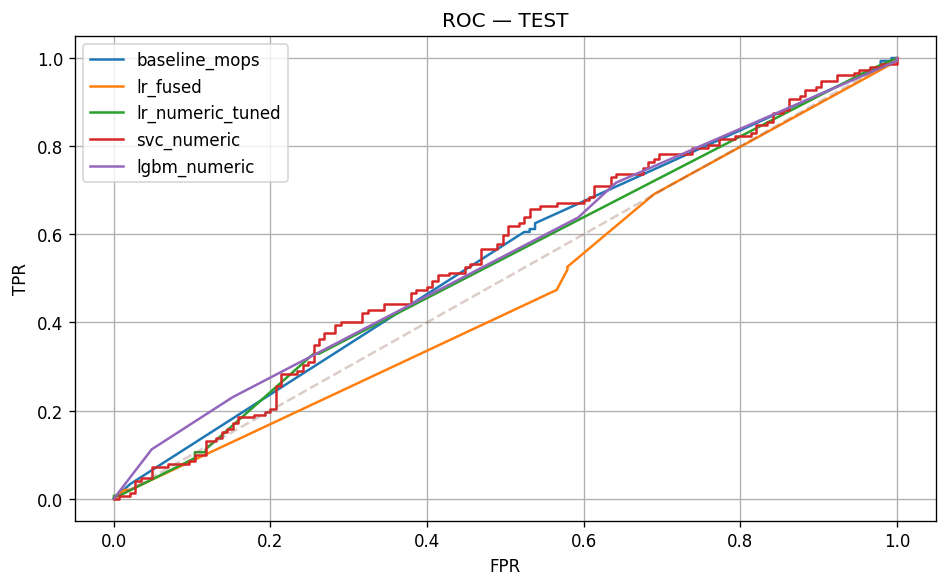

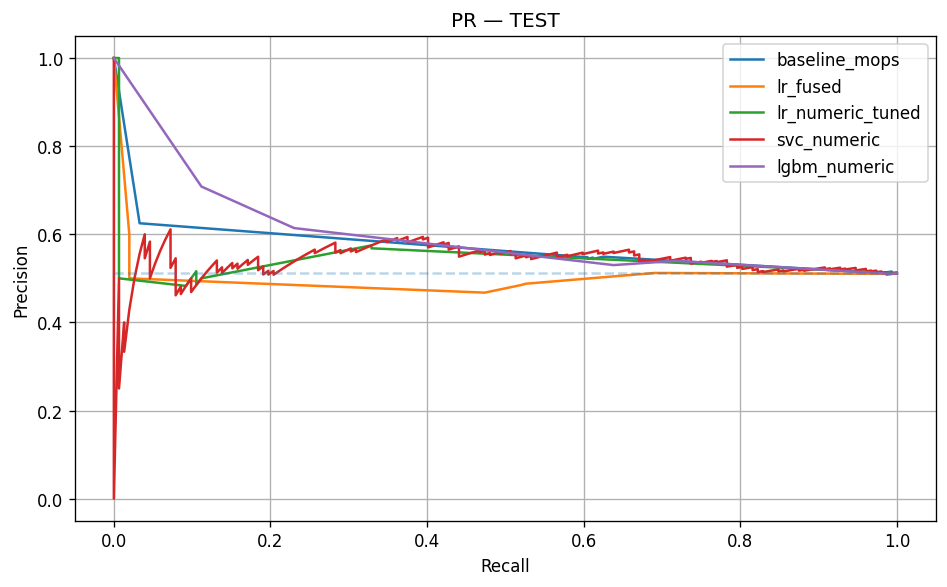

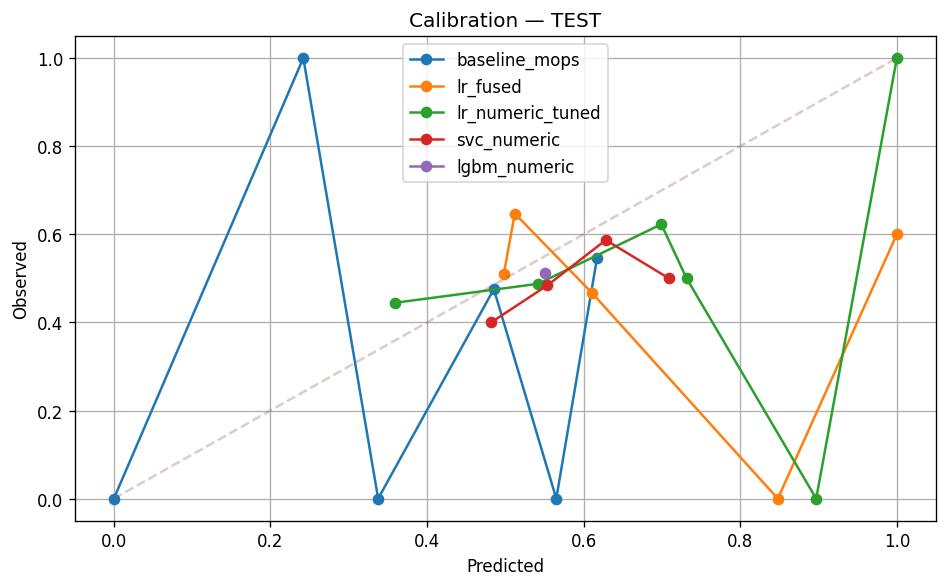


Year-wise TEST AUCs (rows=year):
      baseline_mops  lr_fused  lr_numeric_tuned  svc_numeric  lgbm_numeric
year                                                                      
2024          0.537     0.468             0.535         0.55         0.518
2025          0.558     0.475             0.520         0.56         0.621


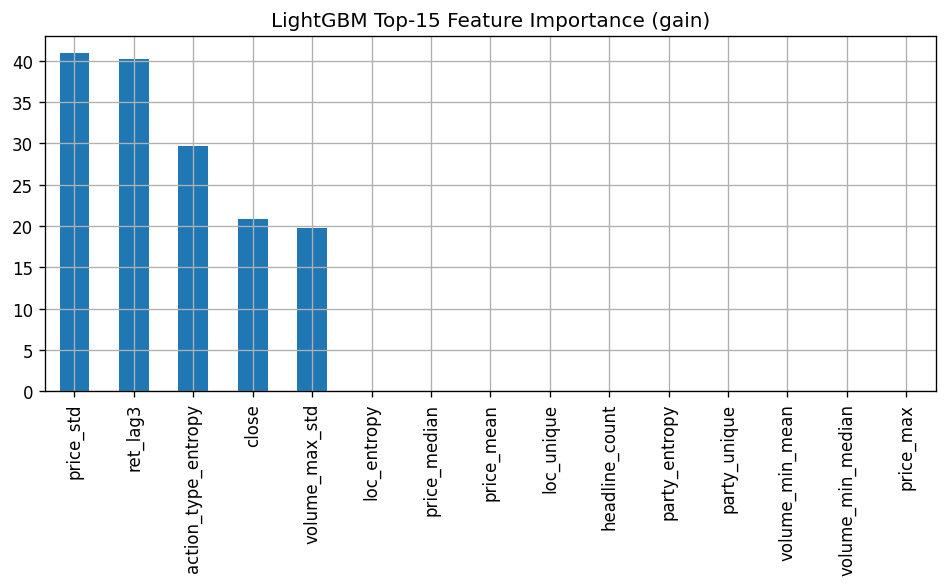

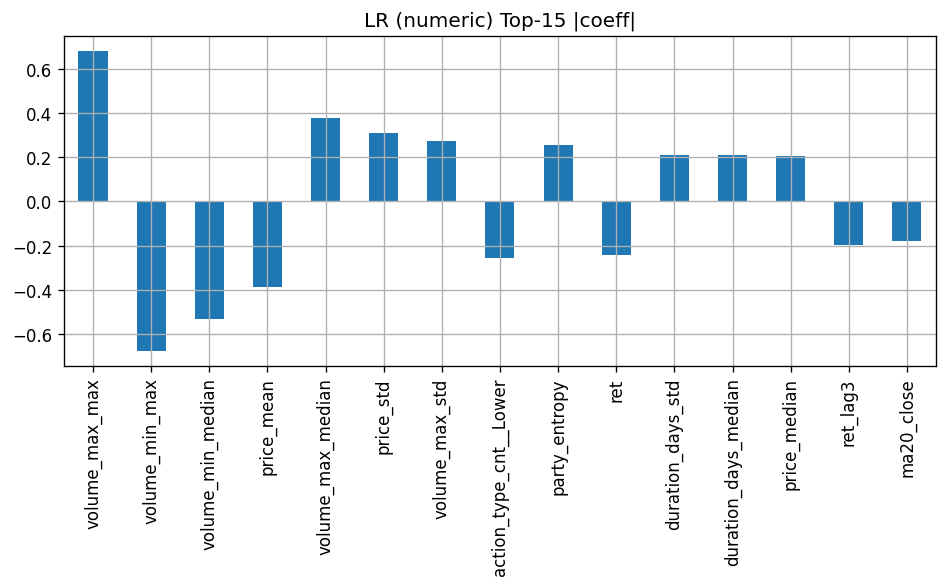


✅ Comparison and visualizations complete.


In [20]:
# =========================
# BLOCK 8: Compare all models + visualizations
# =========================
import numpy as np, pandas as pd
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
                             brier_score_loss, accuracy_score, balanced_accuracy_score)
import joblib, json
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

# ---------- Load data and rebuild numeric features (once) ----------
df = pd.read_parquet(BASE / "data" / "supervised_daily_les.parquet").sort_values("day").reset_index(drop=True)
# leakage-safe price feats at t
df["ret_lag1"]   = df["ret"].shift(1)
df["ret_lag2"]   = df["ret"].shift(2)
df["ret_lag3"]   = df["ret"].shift(3)
df["ma5_close"]  = df["close"].rolling(5, min_periods=5).mean()
df["ma20_close"] = df["close"].rolling(20, min_periods=20).mean()
need = ["ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]
df = df.dropna(subset=need).reset_index(drop=True)

y  = df["y_bin"].astype(int).values
w  = df.get("w_invvar", pd.Series(np.ones(len(df)))).astype(float).values
day= pd.to_datetime(df["day"])
m_train = df["split"].eq("train").values
m_val   = df["split"].eq("val").values
m_test  = df["split"].eq("test").values

# Helper: metrics
def metrics_from_p(p, y, w):
    out = {}
    out["logloss"] = log_loss(y, p, sample_weight=w, labels=[0,1])
    out["brier"]   = brier_score_loss(y, p, sample_weight=w)
    out["acc"]     = accuracy_score(y, p>=0.5)
    out["bacc"]    = balanced_accuracy_score(y, p>=0.5)
    try: out["auc"] = roc_auc_score(y, p)
    except: out["auc"] = np.nan
    out["ap"]      = average_precision_score(y, p)
    return out

def yearwise_auc(day, p, y):
    d = pd.DataFrame({"day":day, "p":p, "y":y})
    d["year"] = d["day"].dt.year
    return d.groupby("year").apply(lambda g: roc_auc_score(g["y"], g["p"]) if g["y"].nunique()>1 else np.nan)

results = {}
roc_curves = {}  # store (y, p, mask) for plotting

# ---------- 1) Benchmark-only LR (recompute) ----------
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

num_cols_base = ["close","ret","ret_lag1","ret_lag2","ret_lag3","ma5_close","ma20_close"]

def take(mask, cols):
    X = df.loc[mask, cols].astype(float).values
    return X, y[mask], w[mask], day[mask]

Xtr, ytr, wtr, dtr = take(m_train, num_cols_base)
Xva, yva, wva, dva = take(m_val,   num_cols_base)
Xte, yte, wte, dte = take(m_test,  num_cols_base)

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr); Xva_s = sc.transform(Xva); Xte_s = sc.transform(Xte)

lr_base = LogisticRegression(solver="saga", penalty="l2", C=1.0, max_iter=5000,
                             class_weight="balanced", n_jobs=-1, random_state=SEED)
lr_base.fit(Xtr_s, ytr, sample_weight=wtr)
cal_base = CalibratedClassifierCV(lr_base, method="isotonic", cv="prefit")
cal_base.fit(Xva_s, yva, sample_weight=wva)

p_tr = cal_base.predict_proba(Xtr_s)[:,1]
p_va = cal_base.predict_proba(Xva_s)[:,1]
p_te = cal_base.predict_proba(Xte_s)[:,1]

results["baseline_mops"] = {
    "train": metrics_from_p(p_tr, ytr, wtr),
    "val":   metrics_from_p(p_va, yva, wva),
    "test":  metrics_from_p(p_te, yte, wte),
    "year_auc_test": yearwise_auc(dte, p_te, yte)
}
roc_curves["baseline_mops"] = (yte, p_te)

# ---------- 2) LR fused (numeric+text) from saved pipeline (for completeness) ----------
try:
    pipe_fused = joblib.load(BASE / "models" / "lr_fused" / "pipeline.joblib")
    # Build fused features via saved pipeline parts
    # Numeric:
    num_cols_fused = pipe_fused["num_cols"]
    Xtr_num = pipe_fused["scaler_num"].transform(df.loc[m_train, num_cols_fused].astype(float).values)
    Xva_num = pipe_fused["scaler_num"].transform(df.loc[m_val,   num_cols_fused].astype(float).values)
    Xte_num = pipe_fused["scaler_num"].transform(df.loc[m_test,  num_cols_fused].astype(float).values)
    Xtr_num = sparse.csr_matrix(Xtr_num); Xva_num = sparse.csr_matrix(Xva_num); Xte_num = sparse.csr_matrix(Xte_num)
    # Text:
    text_col = "text_day" if "text_day" in df.columns else None
    if text_col is None: df["text_day"] = ""; text_col = "text_day"
    Zw_tr = pipe_fused["tfidf_word"].transform(df.loc[m_train, text_col].astype(str).values)
    Zw_va = pipe_fused["tfidf_word"].transform(df.loc[m_val,   text_col].astype(str).values)
    Zw_te = pipe_fused["tfidf_word"].transform(df.loc[m_test,  text_col].astype(str).values)
    Zc_tr = pipe_fused["tfidf_char"].transform(df.loc[m_train, text_col].astype(str).values)
    Zc_va = pipe_fused["tfidf_char"].transform(df.loc[m_val,   text_col].astype(str).values)
    Zc_te = pipe_fused["tfidf_char"].transform(df.loc[m_test,  text_col].astype(str).values)
    Z_tr  = sparse.hstack([Zw_tr, Zc_tr]).tocsr()
    Z_va  = sparse.hstack([Zw_va, Zc_va]).tocsr()
    Z_te  = sparse.hstack([Zw_te, Zc_te]).tocsr()
    Xtxt_tr = pipe_fused["svd"].transform(Z_tr)
    Xtxt_va = pipe_fused["svd"].transform(Z_va)
    Xtxt_te = pipe_fused["svd"].transform(Z_te)
    Xtxt_tr = pipe_fused["svd_scaler"].transform(Xtxt_tr)
    Xtxt_va = pipe_fused["svd_scaler"].transform(Xtxt_va)
    Xtxt_te = pipe_fused["svd_scaler"].transform(Xtxt_te)
    Xtxt_tr = sparse.csr_matrix(Xtxt_tr); Xtxt_va = sparse.csr_matrix(Xtxt_va); Xtxt_te = sparse.csr_matrix(Xtxt_te)
    # Fuse
    X_tr_f = sparse.hstack([Xtr_num, Xtxt_tr]).tocsr()
    X_va_f = sparse.hstack([Xva_num, Xtxt_va]).tocsr()
    X_te_f = sparse.hstack([Xte_num, Xtxt_te]).tocsr()
    p_tr = pipe_fused["cal"].predict_proba(X_tr_f)[:,1]
    p_va = pipe_fused["cal"].predict_proba(X_va_f)[:,1]
    p_te = pipe_fused["cal"].predict_proba(X_te_f)[:,1]
    results["lr_fused"] = {
        "train": metrics_from_p(p_tr, y[m_train], w[m_train]),
        "val":   metrics_from_p(p_va, y[m_val],   w[m_val]),
        "test":  metrics_from_p(p_te, y[m_test],  w[m_test]),
        "year_auc_test": yearwise_auc(day[m_test], p_te, y[m_test])
    }
    roc_curves["lr_fused"] = (y[m_test], p_te)
except Exception as e:
    print(f"[lr_fused] skipped: {e}")

# ---------- 3) LR numeric tuned ----------
try:
    pipe_num = joblib.load(BASE / "models" / "lr_numeric_tuned" / "pipeline.joblib")
    num_cols = pipe_num["num_cols"]
    Xtr = pipe_num["scaler"].transform(df.loc[m_train, num_cols].astype(float).values)
    Xva = pipe_num["scaler"].transform(df.loc[m_val,   num_cols].astype(float).values)
    Xte = pipe_num["scaler"].transform(df.loc[m_test,  num_cols].astype(float).values)
    p_tr = pipe_num["cal"].predict_proba(Xtr)[:,1]
    p_va = pipe_num["cal"].predict_proba(Xva)[:,1]
    p_te = pipe_num["cal"].predict_proba(Xte)[:,1]
    results["lr_numeric_tuned"] = {
        "train": metrics_from_p(p_tr, y[m_train], w[m_train]),
        "val":   metrics_from_p(p_va, y[m_val],   w[m_val]),
        "test":  metrics_from_p(p_te, y[m_test],  w[m_test]),
        "year_auc_test": yearwise_auc(day[m_test], p_te, y[m_test])
    }
    roc_curves["lr_numeric_tuned"] = (y[m_test], p_te)
except Exception as e:
    print(f"[lr_numeric_tuned] skipped: {e}")

# ---------- 4) LinearSVC numeric ----------
try:
    pipe_svc = joblib.load(BASE / "models" / "svc_numeric" / "pipeline.joblib")
    num_cols = pipe_svc["num_cols"]
    Xtr = pipe_svc["scaler"].transform(df.loc[m_train, num_cols].astype(float).values)
    Xva = pipe_svc["scaler"].transform(df.loc[m_val,   num_cols].astype(float).values)
    Xte = pipe_svc["scaler"].transform(df.loc[m_test,  num_cols].astype(float).values)
    p_tr = pipe_svc["cal"].predict_proba(Xtr)[:,1]
    p_va = pipe_svc["cal"].predict_proba(Xva)[:,1]
    p_te = pipe_svc["cal"].predict_proba(Xte)[:,1]
    results["svc_numeric"] = {
        "train": metrics_from_p(p_tr, y[m_train], w[m_train]),
        "val":   metrics_from_p(p_va, y[m_val],   w[m_val]),
        "test":  metrics_from_p(p_te, y[m_test],  w[m_test]),
        "year_auc_test": yearwise_auc(day[m_test], p_te, y[m_test])
    }
    roc_curves["svc_numeric"] = (y[m_test], p_te)
except Exception as e:
    print(f"[svc_numeric] skipped: {e}")

# ---------- 5) LightGBM numeric ----------
try:
    meta = joblib.load(BASE / "models" / "lgbm_numeric" / "meta.joblib")
    gbm = lgb.Booster(model_file=str(BASE / "models" / "lgbm_numeric" / "model.txt"))
    sc   = meta["scaler"]; num_cols = meta["num_cols"]; best_iter = meta["best_iter"]
    Xtr = sc.transform(df.loc[m_train, num_cols].astype(float).values)
    Xva = sc.transform(df.loc[m_val,   num_cols].astype(float).values)
    Xte = sc.transform(df.loc[m_test,  num_cols].astype(float).values)
    p_tr = gbm.predict(Xtr, num_iteration=best_iter)
    p_va = gbm.predict(Xva, num_iteration=best_iter)
    p_te = gbm.predict(Xte, num_iteration=best_iter)
    results["lgbm_numeric"] = {
        "train": metrics_from_p(p_tr, y[m_train], w[m_train]),
        "val":   metrics_from_p(p_va, y[m_val],   w[m_val]),
        "test":  metrics_from_p(p_te, y[m_test],  w[m_test]),
        "year_auc_test": yearwise_auc(day[m_test], p_te, y[m_test])
    }
    roc_curves["lgbm_numeric"] = (y[m_test], p_te)
except Exception as e:
    print(f"[lgbm_numeric] skipped: {e}")

# ---------- Comparison table ----------
rows = []
for name, d in results.items():
    rows.append([name, "train", d["train"]["auc"], d["train"]["ap"], d["train"]["logloss"]])
    rows.append([name, "val",   d["val"]["auc"],   d["val"]["ap"],   d["val"]["logloss"]])
    rows.append([name, "test",  d["test"]["auc"],  d["test"]["ap"],  d["test"]["logloss"]])
comp = pd.DataFrame(rows, columns=["model","split","AUC","AP","LogLoss"])
print("\n=== Model comparison (AUC/AP/LogLoss) ===")
print(comp.pivot(index="model", columns="split", values="AUC").round(3))
print("\nFull table:")
print(comp.round(3).to_string(index=False))

# ---------- ROC & PR curves (TEST) ----------
from sklearn.metrics import roc_curve, precision_recall_curve
plt.figure()
for name, (yt, pt) in roc_curves.items():
    fpr, tpr, _ = roc_curve(y[m_test], pt)
    plt.plot(fpr, tpr, label=f"{name}")
plt.plot([0,1],[0,1],'--',alpha=0.3)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — TEST"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
for name, (yt, pt) in roc_curves.items():
    prec, rec, _ = precision_recall_curve(y[m_test], pt)
    plt.plot(rec, prec, label=f"{name}")
base = y[m_test].mean()
plt.hlines(base, 0, 1, linestyles='--', alpha=0.3)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR — TEST"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- Calibration on TEST ----------
from sklearn.calibration import calibration_curve
plt.figure()
for name, (yt, pt) in roc_curves.items():
    prob_true, prob_pred = calibration_curve(y[m_test], pt, n_bins=10, strategy="uniform")
    plt.plot(prob_pred, prob_true, marker='o', label=name)
plt.plot([0,1],[0,1],'--',alpha=0.3)
plt.xlabel("Predicted"); plt.ylabel("Observed"); plt.title("Calibration — TEST"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- Year-wise AUC (TEST) ----------
yw = pd.DataFrame({name: vals for name, vals in {k: v["year_auc_test"] for k,v in results.items()}.items()})
print("\nYear-wise TEST AUCs (rows=year):")
print(yw.round(3).to_string())

# ---------- Feature importance (LGBM) & Coeffs (LR numeric) ----------
try:
    # LGBM feature importance
    plt.figure()
    imp = pd.Series(gbm.feature_importance(importance_type="gain"), index=num_cols).sort_values(ascending=False).head(15)
    imp.plot(kind="bar")
    plt.title("LightGBM Top-15 Feature Importance (gain)")
    plt.tight_layout(); plt.show()
except Exception:
    pass

try:
    # LR numeric coefficients
    pipe_num = joblib.load(BASE / "models" / "lr_numeric_tuned" / "pipeline.joblib")
    beta = pipe_num["lr"].coef_.ravel()
    nc = pipe_num["num_cols"]
    top = pd.Series(beta, index=nc).sort_values(key=np.abs, ascending=False).head(15)
    plt.figure()
    top.plot(kind="bar")
    plt.title("LR (numeric) Top-15 |coeff|")
    plt.tight_layout(); plt.show()
except Exception:
    pass

print("\n✅ Comparison and visualizations complete.")


In [21]:
# =========================
# BLOCK Z1 (fixed): EXPORT SNAPSHOT (models + parquets + preds + manifest)
# =========================
import os, sys, json, platform
from pathlib import Path
from datetime import datetime

# 1) Verify BASE exists
try:
    BASE
except NameError:
    raise RuntimeError("BASE is not defined. Run your environment cell first.")

RUN_DIR = Path(BASE)
ROOT    = RUN_DIR.parent
STAMP   = datetime.utcnow().strftime("%Y%m%d-%H%M%S")
ARCHIVE_TGZ = ROOT / f"snapshot_{RUN_DIR.name}_{STAMP}.tar.gz"
ARCHIVE_ZIP = ROOT / f"snapshot_{RUN_DIR.name}_{STAMP}.zip"

# 2) Collect files to export
INCLUDE_DIRS = ["data", "models", "preds"]
files = []
for d in INCLUDE_DIRS:
    p = RUN_DIR / d
    if p.exists():
        for f in p.rglob("*"):
            if f.is_file():
                files.append(f.relative_to(RUN_DIR).as_posix())

# 3) Minimal requirements snapshot
def get_ver(pkg):
    try:
        import importlib
        m = importlib.import_module(pkg)
        return getattr(m, "__version__", "unknown")
    except Exception:
        return "not_installed"

reqs = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": get_ver("numpy"),
    "pandas": get_ver("pandas"),
    "scikit_learn": get_ver("sklearn"),
    "scipy": get_ver("scipy"),
    "matplotlib": get_ver("matplotlib"),
    "lightgbm": get_ver("lightgbm"),
    "category_encoders": get_ver("category_encoders"),
    "statsmodels": get_ver("statsmodels"),
}

# 4) Write MANIFEST.json
manifest = {
    "run_folder": RUN_DIR.name,
    "created_utc": STAMP + "Z",
    "base_path_hint": str(RUN_DIR),
    "include_dirs": INCLUDE_DIRS,
    "files": files,
    "requirements": reqs,
}
(RUN_DIR / "MANIFEST.json").write_text(json.dumps(manifest, indent=2))

# 5) Create .tar.gz (preferred), fallback to .zip if needed
arch_path = None
try:
    import tarfile
    with tarfile.open(ARCHIVE_TGZ, mode="w:gz") as tar:  # correct mode
        tar.add(RUN_DIR, arcname=RUN_DIR.name)
    arch_path = ARCHIVE_TGZ
except Exception as e:
    print(f"[WARN] tar.gz failed ({e}); falling back to ZIP.")
    import zipfile
    with zipfile.ZipFile(ARCHIVE_ZIP, mode="w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        # include MANIFEST and listed files
        zf.write(RUN_DIR / "MANIFEST.json", arcname=str(Path(RUN_DIR.name) / "MANIFEST.json"))
        for rel in files:
            f = RUN_DIR / rel
            if f.exists():
                zf.write(f, arcname=str(Path(RUN_DIR.name) / rel))
    arch_path = ARCHIVE_ZIP

size_mb = arch_path.stat().st_size / 1e6
print(f"📦 Snapshot created: {arch_path} ({size_mb:.2f} MB)")
print(f"Contains {len(files)} files from {INCLUDE_DIRS} + MANIFEST.json")

# 6) Offer download in Colab
try:
    from google.colab import files as colab_files  # type: ignore
    colab_files.download(str(arch_path))
except Exception:
    print("Note: If not in Colab, download the archive from the path above.")


📦 Snapshot created: /content/runs/snapshot_20250925-220230_20250925-231433.tar.gz (68.32 MB)
Contains 16 files from ['data', 'models', 'preds'] + MANIFEST.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# =========================
# BLOCK Z-FIGS: Save & download all figures
# - Saves any currently open Matplotlib figures to BASE/figs
# - Collects all image files under BASE (png/jpg/svg/pdf)
# - Zips them and triggers a download in Colab
# =========================
import os, re, io, sys, json, time, glob, tarfile, zipfile
from pathlib import Path
from datetime import datetime

# 0) Ensure BASE exists
try:
    BASE
except NameError:
    raise RuntimeError("BASE is not defined. Run your environment block first.")
RUN_DIR = Path(BASE)
FIG_DIR = RUN_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save any currently open Matplotlib figures (if any are in memory)
try:
    import matplotlib
    from matplotlib import pyplot as plt
    managers = matplotlib._pylab_helpers.Gcf.get_all_fig_managers()
    ts = datetime.utcnow().strftime("%Y%m%d-%H%M%S")
    saved_count = 0
    for i, m in enumerate(managers, 1):
        fig = m.canvas.figure
        out = FIG_DIR / f"figure_{ts}_{i:02d}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        saved_count += 1
    print(f"Saved {saved_count} currently open Matplotlib figure(s) to {FIG_DIR}.")
except Exception as e:
    print(f"[WARN] Could not access Matplotlib figures: {e}")

# 2) Collect all image files under BASE (figs produced earlier, or saved by code)
patterns = ["**/*.png", "**/*.jpg", "**/*.jpeg", "**/*.svg", "**/*.pdf"]
image_files = []
for pat in patterns:
    image_files.extend([p for p in RUN_DIR.glob(pat) if p.is_file()])

# De-duplicate and sort
image_files = sorted(set(image_files))

if not image_files:
    print("No image files found under BASE. Re-run plotting blocks (e.g., Block 8) and then rerun this cell.")
else:
    # 3) Zip them for download
    STAMP = datetime.utcnow().strftime("%Y%m%d-%H%M%S")
    ZIP_PATH = RUN_DIR.parent / f"figures_{RUN_DIR.name}_{STAMP}.zip"
    with zipfile.ZipFile(ZIP_PATH, mode="w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
        for f in image_files:
            # keep relative path inside the run folder
            arcname = Path(RUN_DIR.name) / f.relative_to(RUN_DIR)
            zf.write(f, arcname=str(arcname))
    print(f"📦 Packaged {len(image_files)} figure file(s) into: {ZIP_PATH}")

    # 4) Trigger download in Colab (if available)
    try:
        from google.colab import files as colab_files  # type: ignore
        colab_files.download(str(ZIP_PATH))
    except Exception:
        print("Not in Colab download context. Manually fetch the ZIP from the path above.")


Saved 0 currently open Matplotlib figure(s) to /content/runs/20250925-220230/figs.
No image files found under BASE. Re-run plotting blocks (e.g., Block 8) and then rerun this cell.
